In [4]:
from huggingface_hub import HfApi
HfApi().delete_folder(path_in_repo="logs", repo_id="akcit-rl/info-gainme", repo_type="dataset")

/Users/danielmachado/Documents/ceia/akcit-rl/info-gainme_dev/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CommitInfo(commit_url='https://huggingface.co/datasets/akcit-rl/info-gainme/commit/beadabfa121e135f39459872d14bd73f5677ed8d', commit_message='Delete folder logs with huggingface_hub', commit_description='', oid='beadabfa121e135f39459872d14bd73f5677ed8d', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/akcit-rl/info-gainme', endpoint='https://huggingface.co', repo_type='dataset', repo_id='akcit-rl/info-gainme'), pr_revision=None, pr_num=None)

In [5]:
import pandas as pd

# Judge Analysis

In [6]:
df_oracle = pd.read_csv("outputs/judge_oracle_summary.csv")
df_pruner = pd.read_csv("outputs/judge_pruner_summary.csv")

# Filter _ont
df_oracle = df_oracle[~df_oracle['experiment'].str.contains('_ont')]
df_pruner = df_pruner[~df_pruner['experiment'].str.contains('_ont')]

df_oracle['dataset'] = df_oracle['target_id'].apply(lambda x: x.split(":")[0])
df_pruner['dataset'] = df_pruner['target_id'].apply(lambda x: x.split(":")[0])

In [7]:
exps_with_kickoff = df_oracle[df_oracle['experiment'].str.contains('kickoff')]['experiment'].unique()

exps_with_kickoff

array([], dtype=object)

In [8]:
df_pruner

,conversation_path,judge_eval_path,experiment,target_id,target_label,seeker_model,oracle_model,pruner_model,judge_model,n_turns,n_ok,n_errors,mean_jaccard,n_target_removed_by_qwen,n_target_removed_by_judge,dataset
66,models/s_Llama-3.2-1B-Instruct__o_Qwen3-8B__p_...,models/s_Llama-3.2-1B-Instruct__o_Qwen3-8B__p_...,diseases_160_llama1b_fo_no_cot,disease:abscess_of_nose:0,abscess of nose,Llama-3.2-1B-Instruct,Qwen3-8B,Qwen3-8B,gpt-oss-120b,1,1,0,1.000000,0,0,disease
67,models/s_Llama-3.2-1B-Instruct__o_Qwen3-8B__p_...,models/s_Llama-3.2-1B-Instruct__o_Qwen3-8B__p_...,diseases_160_llama1b_fo_no_cot,disease:achalasia:1,achalasia,Llama-3.2-1B-Instruct,Qwen3-8B,Qwen3-8B,gpt-oss-120b,30,30,0,0.998750,0,0,disease
68,models/s_Llama-3.2-1B-Instruct__o_Qwen3-8B__p_...,models/s_Llama-3.2-1B-Instruct__o_Qwen3-8B__p_...,diseases_160_llama1b_fo_no_cot,disease:amblyopia:6,amblyopia,Llama-3.2-1B-Instruct,Qwen3-8B,Qwen3-8B,gpt-oss-120b,9,9,0,0.844887,3,1,disease
69,models/s_Llama-3.2-1B-Instruct__o_Qwen3-8B__p_...,models/s_Llama-3.2-1B-Instruct__o_Qwen3-8B__p_...,diseases_160_llama1b_fo_no_cot,disease:coagulation_bleeding_disorder:29,coagulation (bleeding) disorder,Llama-3.2-1B-Instruct,Qwen3-8B,Qwen3-8B,gpt-oss-120b,30,30,0,0.994467,0,0,disease
70,models/s_Llama-3.2-1B-Instruct__o_Qwen3-8B__p_...,models/s_Llama-3.2-1B-Instruct__o_Qwen3-8B__p_...,diseases_160_llama1b_fo_no_cot,disease:dislocation_of_the_vertebra:36,dislocation of the vertebra,Llama-3.2-1B-Instruct,Qwen3-8B,Qwen3-8B,gpt-oss-120b,18,18,0,0.383383,13,2,disease
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
281,models/s_Olmo-3-7B-Instruct__o_Qwen3-8B__p_Qwe...,models/s_Olmo-3-7B-Instruct__o_Qwen3-8B__p_Qwe...,diseases_160_olmo3_7b_instruct_fo_no_cot,disease:flat_feet:49,flat feet,Olmo-3-7B-Instruct,Qwen3-8B,Qwen3-8B,gpt-oss-120b,30,30,0,0.964648,1,0,disease
282,models/s_Olmo-3-7B-Instruct__o_Qwen3-8B__p_Qwe...,models/s_Olmo-3-7B-Instruct__o_Qwen3-8B__p_Qwe...,diseases_160_olmo3_7b_instruct_fo_no_cot,disease:infection_of_open_wound:76,infection of open wound,Olmo-3-7B-Instruct,Qwen3-8B,Qwen3-8B,gpt-oss-120b,7,7,0,0.736196,2,0,disease
283,models/s_Olmo-3-7B-Instruct__o_Qwen3-8B__p_Qwe...,models/s_Olmo-3-7B-Instruct__o_Qwen3-8B__p_Qwe...,diseases_160_olmo3_7b_instruct_fo_no_cot,disease:injury_to_the_knee:79,injury to the knee,Olmo-3-7B-Instruct,Qwen3-8B,Qwen3-8B,gpt-oss-120b,30,30,0,0.942095,1,0,disease
284,models/s_Olmo-3-7B-Instruct__o_Qwen3-8B__p_Qwe...,models/s_Olmo-3-7B-Instruct__o_Qwen3-8B__p_Qwe...,diseases_160_olmo3_7b_instruct_fo_no_cot,disease:intracranial_hemorrhage:83,intracranial hemorrhage,Olmo-3-7B-Instruct,Qwen3-8B,Qwen3-8B,gpt-oss-120b,9,9,0,0.908058,1,0,disease


In [9]:
df_oracle[df_oracle["oracle_model"] == "Qwen3-8B"]['agreement'].mean()

np.float64(0.9090186285582463)

In [10]:
df_pruner[df_pruner["oracle_model"] == "Qwen3-8B"]['mean_jaccard'].mean()

np.float64(0.8705724326301273)

In [11]:
df_oracle[["oracle_model", "dataset", "agreement"]].groupby(["dataset", "oracle_model"]).mean()

agreement
dataset oracle_model                  
city    Gemma-3-12B-IT        0.948052
        Qwen3-8B              0.935390
disease Gemma-3-12B-IT        0.907834
        Nemotron-Cascade-8B   0.951711
        Qwen3-8B              0.865309
object  Gemma-3-12B-IT        0.952589
        Qwen3-8B              0.915845

# Question Classfication

In [12]:
import pandas as pd

SAMPLE_INDICES = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150]

def _sample_targets(targets):
    s = sorted(targets)
    return {s[i] for i in SAMPLE_INDICES if i < len(s)}

# Geo
geo = pd.read_csv("data/geo/top_160_pop_cities.csv")
geo_targets = (geo['city_id'].astype(str).map(lambda x: f"city-{x}_run01")).tolist()
geo_sample = _sample_targets(geo_targets)

# Diseases
dis = pd.read_csv("data/diseases/diseases_160.csv").reset_index(drop=True)
dis_targets = dis.apply(
    lambda r: f"disease-{r['disease'].replace(' ', '_')}-{r.name}_run01", axis=1
).tolist()
dis_sample = _sample_targets(dis_targets)

# Objects
obj = pd.read_csv("data/objects/objects_full.csv")
obj['cat_idx'] = obj.groupby('category').cumcount()
obj_targets = obj.apply(
    lambda r: f"object-{r['category'].lower()}-{r['cat_idx']}_run01", axis=1
).tolist()
obj_sample = _sample_targets(obj_targets)

print(f"Sample sizes: geo={len(geo_sample)}, diseases={len(dis_sample)}, objects={len(obj_sample)}")
# Esperado: 16, 16, 16 (16 posições amostradas por domínio)

all_samples = geo_sample.union(dis_sample).union(obj_sample)
print(f"Total unique samples: {len(all_samples)}")

Sample sizes: geo=16, diseases=16, objects=16
Total unique samples: 48


In [13]:
import pandas as pd



df_questions = pd.read_json("outputs/question_classifications.jsonl", lines=True)


with_kickoff_canonical = [exp[:-13] for exp in (df_questions[df_questions['experiment'].str.contains('kickoff')].experiment.unique().tolist())]
with_kickoff_canonical


# Filter sample data
df_questions = df_questions[df_questions.apply(lambda r: r['target'] in all_samples, axis=1)]

# Filter out kickoff experiments
df_questions = df_questions[df_questions['experiment'].apply(lambda x: not any(kc in x for kc in with_kickoff_canonical))]


# Filter out _ont experiments
df_questions = df_questions[~df_questions['experiment'].str.contains('_ont')]


df_questions['seeker'] = df_questions['model_slug'].str.split("__").str[0].str[2:]

df_questions['oracle'] = df_questions['model_slug'].str.split("__").str[1].str[2:]

df_questions['with_prior'] = df_questions['experiment'].str.contains("with_prior")

# Filter oracle Qwen3-8B
df_questions = df_questions[df_questions['oracle'] == "Qwen3-8B"]

df_questions

,turns_path,experiment,model_slug,domain,mode,cot,target,num_turns,turns,analysis_model,seeker,oracle,with_prior
866,outputs/models/s_Llama-3.2-1B-Instruct__o_Qwen...,diseases_160_llama1b_fo_no_cot,s_Llama-3.2-1B-Instruct__o_Qwen3-8B__p_Qwen3-8B,diseases,fo,False,disease-abscess_of_nose-0_run01,1,"[{'turn': 1, 'question': '[Turn 1/30] [Compute...",Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,Llama-3.2-1B-Instruct,Qwen3-8B,False
892,outputs/models/s_Llama-3.2-1B-Instruct__o_Qwen...,diseases_160_llama1b_fo_no_cot,s_Llama-3.2-1B-Instruct__o_Qwen3-8B__p_Qwen3-8B,diseases,fo,False,disease-common_cold-30_run01,16,"[{'turn': 1, 'question': '[Turn 1/30] [Compute...",Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,Llama-3.2-1B-Instruct,Qwen3-8B,False
905,outputs/models/s_Llama-3.2-1B-Instruct__o_Qwen...,diseases_160_llama1b_fo_no_cot,s_Llama-3.2-1B-Instruct__o_Qwen3-8B__p_Qwen3-8B,diseases,fo,False,disease-asthma-10_run01,22,"[{'turn': 1, 'question': '[Turn 1/30] [Compute...",Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,Llama-3.2-1B-Instruct,Qwen3-8B,False
921,outputs/models/s_Llama-3.2-1B-Instruct__o_Qwen...,diseases_160_llama1b_fo_no_cot,s_Llama-3.2-1B-Instruct__o_Qwen3-8B__p_Qwen3-8B,diseases,fo,False,disease-bladder_obstruction-20_run01,29,"[{'turn': 1, 'question': '[Turn 1/30] [Compute...",Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,Llama-3.2-1B-Instruct,Qwen3-8B,False
1205,outputs/models/s_Olmo-3-7B-Instruct__o_Qwen3-8...,diseases_160_olmo3_7b_instruct_fo_no_cot,s_Olmo-3-7B-Instruct__o_Qwen3-8B__p_Qwen3-8B,diseases,fo,False,disease-dyshidrosis-40_run01,3,"[{'turn': 1, 'question': 'Is the target diseas...",Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,Olmo-3-7B-Instruct,Qwen3-8B,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39629,outputs/models/s_phi-4__o_Qwen3-8B__p_Qwen3-8B...,geo_160_phi4_po_no_cot,s_phi-4__o_Qwen3-8B__p_Qwen3-8B,geo,po,False,city-1267995_run01,29,"[{'turn': 1, 'question': 'Is the city located ...",google/gemma-4-31B-it,phi-4,Qwen3-8B,False
39630,outputs/models/s_phi-4__o_Qwen3-8B__p_Qwen3-8B...,geo_160_phi4_po_no_cot,s_phi-4__o_Qwen3-8B__p_Qwen3-8B,geo,po,False,city-2298890_run01,28,"[{'turn': 1, 'question': 'Is the target city i...",google/gemma-4-31B-it,phi-4,Qwen3-8B,False
39631,outputs/models/s_phi-4__o_Qwen3-8B__p_Qwen3-8B...,geo_160_phi4_io_no_cot,s_phi-4__o_Qwen3-8B__p_Qwen3-8B,geo,fo,False,city-1811103_run01,30,"[{'turn': 1, 'question': 'Is the target city i...",google/gemma-4-31B-it,phi-4,Qwen3-8B,False
39632,outputs/models/s_phi-4__o_Qwen3-8B__p_Qwen3-8B...,geo_160_phi4_po_no_cot,s_phi-4__o_Qwen3-8B__p_Qwen3-8B,geo,po,False,city-1790630_run01,30,"[{'turn': 1, 'question': 'Is the target city l...",google/gemma-4-31B-it,phi-4,Qwen3-8B,False


In [14]:
df_questions.groupby('seeker').size()

seeker
Gemma-3-12B-IT                             88
Gemma-3-4B-IT                              88
Llama-3.1-8B-Instruct                     132
Llama-3.2-1B-Instruct                      15
Llama-3.2-3B-Instruct                      88
Nemotron-Mini-4B-Instruct                   7
OLMo-3-7B-Instruct                         88
OLMo-3-7B-Think                            86
Olmo-3-7B-Instruct                         88
Olmo-3-7B-Think                            88
Olmo-3.1-32B-Think                         16
Phi-4-mini-instruct                       132
Phi-4-mini-reasoning                       70
Phi-4-reasoning                           132
Qwen-Qwen3-235B-A22B-Instruct-2507-FP8    132
Qwen3-0.6B                                176
Qwen3-30B-A3B-Instruct-2507               180
Qwen3-30B-A3B-Thinking-2507               180
Qwen3-4B-Instruct-2507                    132
Qwen3-4B-Thinking-2507                    132
Qwen3-8B                                  360
google-gemma-4-31B-it      

In [15]:
stratum = ['seeker', 'oracle', 'domain', 'mode', 'cot', 'with_prior']


# Explodir turns → 1 linha por turno
turns = df_questions.explode('turns').reset_index(drop=True)

turns['seeker'] = turns['seeker'].str.replace(r'^OLMo-', 'Olmo-', regex=True)


turns = pd.concat([
    turns.drop(columns=['turns']),
    turns['turns'].apply(lambda t: {
        'turn': t.get('turn'),
        'question': t.get('question'),
        'oracle_answer': t.get('oracle_answer'),
        **t.get('classification', {'question_type': 'MISSING', 'redundancy': 'MISSING', 'subclasses': []}),
    }).apply(pd.Series)
], axis=1)

# Flag de redundância
turns['is_redundant'] = turns['redundancy'].isin(['exact_duplicate', 'semantic_equivalent', 'strictly_implied'])

turns

,turns_path,experiment,model_slug,domain,mode,cot,target,num_turns,analysis_model,seeker,...,question,oracle_answer,question_type_rationale,question_type,subclasses_rationale,subclasses,redundancy_rationale,redundancy,error,is_redundant
0,outputs/models/s_Llama-3.2-1B-Instruct__o_Qwen...,diseases_160_llama1b_fo_no_cot,s_Llama-3.2-1B-Instruct__o_Qwen3-8B__p_Qwen3-8B,diseases,fo,False,disease-abscess_of_nose-0_run01,1,Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,Llama-3.2-1B-Instruct,...,Do you have a nose abscess?,Yes! You found the target!,"Asks about a specific medical condition, namin...",direct_guess,,[],"This is the first turn, so there is no prior i...",none,NaN,False
1,outputs/models/s_Llama-3.2-1B-Instruct__o_Qwen...,diseases_160_llama1b_fo_no_cot,s_Llama-3.2-1B-Instruct__o_Qwen3-8B__p_Qwen3-8B,diseases,fo,False,disease-common_cold-30_run01,16,Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,Llama-3.2-1B-Instruct,...,Do you have an allergy to animals?,No,Asks about a medical condition involving immun...,semantic,Refers to a broad medical category of conditio...,[hierarchical_category],"This is the first question, so no prior inform...",none,NaN,False
2,outputs/models/s_Llama-3.2-1B-Instruct__o_Qwen...,diseases_160_llama1b_fo_no_cot,s_Llama-3.2-1B-Instruct__o_Qwen3-8B__p_Qwen3-8B,diseases,fo,False,disease-common_cold-30_run01,16,Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,Llama-3.2-1B-Instruct,...,Do you have a thyroid cancer?,No,"Names a specific disease as a candidate, direc...",direct_guess,,[],This is the first time this specific guess is ...,none,NaN,False
3,outputs/models/s_Llama-3.2-1B-Instruct__o_Qwen...,diseases_160_llama1b_fo_no_cot,s_Llama-3.2-1B-Instruct__o_Qwen3-8B__p_Qwen3-8B,diseases,fo,False,disease-common_cold-30_run01,16,Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,Llama-3.2-1B-Instruct,...,Do you have a thyroid nodule?,No,Asks about a specific medical condition relate...,semantic,Targets a fine-grained medical condition that ...,[fine_grained_category],This is the first mention of thyroid nodules; ...,none,NaN,False
4,outputs/models/s_Llama-3.2-1B-Instruct__o_Qwen...,diseases_160_llama1b_fo_no_cot,s_Llama-3.2-1B-Instruct__o_Qwen3-8B__p_Qwen3-8B,diseases,fo,False,disease-common_cold-30_run01,16,Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,Llama-3.2-1B-Instruct,...,Do you have a thyroid cancer?,No,Repeats the same direct guess of a specific di...,direct_guess,,[],"This exact question was asked in turn 2, makin...",exact_duplicate,NaN,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56874,outputs/models/s_phi-4__o_Qwen3-8B__p_Qwen3-8B...,geo_160_phi4_po_no_cot,s_phi-4__o_Qwen3-8B__p_Qwen3-8B,geo,po,False,city-344979_run01,30,google/gemma-4-31B-it,phi-4,...,Is the city located on the Atlantic Ocean isla...,No,Asks about specific islands.,semantic,Fine-grained geographical category.,[fine_grained_category],New specific location probe.,none,NaN,False
56875,outputs/models/s_phi-4__o_Qwen3-8B__p_Qwen3-8B...,geo_160_phi4_po_no_cot,s_phi-4__o_Qwen3-8B__p_Qwen3-8B,geo,po,False,city-344979_run01,30,google/gemma-4-31B-it,phi-4,...,Is the city located in an African country that...,Yes,Asks about a geographical property (landlocked).,semantic,Combines landlocked status with exclusionary c...,[compound_predicate],New property probe.,none,NaN,False
56876,outputs/models/s_phi-4__o_Qwen3-8B__p_Qwen3-8B...,geo_160_phi4_po_no_cot,s_phi-4__o_Qwen3-8B__p_Qwen3-8B,geo,po,False,city-344979_run01,30,google/gemma-4-31B-it,phi-4,...,Can you confirm if the city is in a landlocked...,Yes,Asks about a geographical property (landlocked).,semantic,Broad categorical attribute (landlocked).,[fine_grained_category],This is a semantic equivalent of the core quer...,semantic_equivalent,NaN,True
56877,outputs/models/s_phi-4__o_Qwen3-8B__p_Qwen3-8B...,geo_160_phi4_po_no_cot,s_phi-4__o_Qwen3-8B__p_Qwen3-8B,geo,po,False,city-344979_run01,30,google/gemma-4-31B-it,phi-4,...,"Is the city in one of the countries of Zambia,...",No,Asks a

In [16]:
summary_class_by_stratum = (
    turns
    .groupby(stratum)
    .agg(
        n_turns=('question_type', 'count'),
        pct_semantic=('question_type', lambda x: (x == 'semantic').mean() * 100),
        pct_malformed=('question_type', lambda x: (x == 'malformed').mean() * 100),
        pct_direct_guess=('question_type', lambda x: (x == 'direct_guess').mean() * 100),
        pct_missing=('question_type', lambda x: (x == 'MISSING').mean() * 100),
        pct_redundant=('is_redundant', 'mean'),
    )
    .assign(pct_redundant=lambda d: d['pct_redundant'] * 100)
    .sort_values('n_turns', ascending=False)
    .round(1)
    .reset_index()   # ← cada elemento do stratum vira coluna
)

summary_class_by_stratum_po = summary_class_by_stratum[summary_class_by_stratum['mode'] == 'po'].drop(columns=['mode'])
summary_class_by_stratum_fo = summary_class_by_stratum[summary_class_by_stratum['mode'] == 'fo'].drop(columns=['mode'])
summary_class_by_stratum_io = summary_class_by_stratum[summary_class_by_stratum['mode'] == 'io'].drop(columns=['mode'])


summary_class_by_seeker = (
    turns
    .groupby('seeker')
    .agg(
        n_turns=('question_type', 'count'),
        pct_semantic=('question_type', lambda x: (x == 'semantic').mean() * 100),
        pct_malformed=('question_type', lambda x: (x == 'malformed').mean() * 100),
        pct_direct_guess=('question_type', lambda x: (x == 'direct_guess').mean() * 100),
        pct_missing=('question_type', lambda x: (x == 'MISSING').mean() * 100),
        pct_redundant=('is_redundant', 'mean'),
    )
    .assign(pct_redundant=lambda d: d['pct_redundant'] * 100)
    .sort_values('n_turns', ascending=False)
    .round(1)
    .reset_index()   # ← cada elemento do stratum vira coluna
)



In [17]:
malformed_seekers = summary_class_by_seeker[summary_class_by_seeker['pct_malformed'] > 50]['seeker'].tolist()
print("Seekers with >50% malformed questions:", malformed_seekers)

Seekers with >50% malformed questions: ['Qwen3-0.6B', 'Phi-4-reasoning', 'Llama-3.2-1B-Instruct']


In [46]:
summary_class_by_seeker

,seeker,n_turns,pct_semantic,pct_malformed,pct_direct_guess,pct_missing,pct_redundant
0,Qwen3-8B,6067,90.0,2.9,6.9,0.0,7.7
1,google-gemma-4-E4B-it,5176,71.9,1.5,23.0,0.0,6.1
2,Qwen3-0.6B,4490,8.3,75.6,6.7,0.0,69.9
3,google-gemma-4-31B-it,4068,70.8,2.8,22.2,0.0,1.9
4,Olmo-3-7B-Instruct,3136,61.4,13.0,24.5,0.0,4.0
5,Phi-4-mini-instruct,2932,53.6,8.0,28.5,0.0,11.8
6,Qwen3-30B-A3B-Instruct-2507,2875,86.1,0.8,13.0,0.0,3.0
7,Qwen3-4B-Instruct-2507,2706,91.4,2.4,5.7,0.0,5.0
8,Olmo-3-7B-Think,2336,67.2,11.1,17.7,0.0,11.9
9,Qwen3-30B-A3B-Thinking-2507,2327,65.3,3.7,16.0,0.0,2.4


In [35]:
summary_class_by_stratum_po.sort_values("pct_malformed", ascending=False)

,seeker,oracle,domain,cot,n_turns,pct_semantic,pct_malformed,pct_direct_guess,pct_missing,pct_redundant
136,Phi-4-reasoning,Qwen3-8B,objects,True,107,0.0,100.0,0.0,0.0,60.7
103,Phi-4-reasoning,Qwen3-8B,diseases,True,247,0.0,89.2,0.0,0.0,54.2
110,Phi-4-reasoning,Qwen3-8B,geo,True,231,9.6,77.0,1.9,0.0,55.9
127,Phi-4-mini-reasoning,Qwen3-8B,objects,True,180,11.0,68.6,6.2,0.0,31.0
138,Phi-4-mini-reasoning,Qwen3-8B,geo,True,70,38.6,57.1,4.3,0.0,2.9
...,...,...,...,...,...,...,...,...,...,...
81,phi-4,Qwen3-8B,geo,False,313,84.7,0.0,15.3,0.0,3.5
75,google-gemma-4-31B-it,Qwen3-8B,geo,True,341,80.1,0.0,19.4,0.0,0.6
74,google-gemma-4-31B-it,Qwen3-8B,diseases,False,344,58.3,0.0,33.7,0.0,0.8
56,Qwen-Qwen3-235B-A22B-Instruct-2507-FP8,Qwen3-8B,diseases,False,417,66.2,0.0,33.8,0.0,1.0


In [ ]:
summary_class_by_seeker.sort_values("pct_malformed", ascending=False)

,seeker,n_turns,pct_semantic,pct_malformed,pct_direct_guess,pct_missing,pct_redundant
20,Llama-3.2-1B-Instruct,303,5.0,76.6,18.5,0.0,52.5
2,Qwen3-0.6B,4490,8.3,75.6,6.7,0.0,69.9
18,Phi-4-reasoning,1116,3.7,71.5,0.4,0.0,46.0
19,Phi-4-mini-reasoning,912,18.2,35.5,10.5,0.0,14.4
4,Olmo-3-7B-Instruct,3136,61.4,13.0,24.5,0.0,4.0
8,Olmo-3-7B-Think,2336,67.2,11.1,17.7,0.0,11.9
5,Phi-4-mini-instruct,2932,53.6,8.0,28.5,0.0,11.8
22,Olmo-3.1-32B-Think,93,30.5,7.0,9.1,0.0,0.5
14,Qwen3-4B-Thinking-2507,1917,87.1,4.3,8.1,0.0,1.7
9,Qwen3-30B-A3B-Thinking-2507,2327,65.3,3.7,16.0,0.0,2.4


In [99]:
TOP_SUBS = ['hierarchical_category', 'fine_grained_category', 'relational',
            'statement', 'open_ended', 'compound_predicate', 'quantitative_threshold',
            'comparative', 'meta_strategy']

turns_classified = turns[turns['question_type'] != 'MISSING'].copy()

# stratum = ['seeker', 'oracle', 'domain', 'mode', 'cot']
stratum = ['seeker', 'mode', 'cot', 'with_prior']

# Denominador: total de turnos classificados por stratum
n_per_stratum = turns_classified.groupby(stratum).size().rename('n_turns')

# Contagem de cada subclasse por stratum
sub_counts = (
    turns_classified
    .explode('subclasses')
    .loc[lambda df: df['subclasses'].isin(TOP_SUBS)]
    .groupby(stratum + ['subclasses'])
    .size()
    .unstack('subclasses', fill_value=0)
)

# Percentual + join com n_turns + reset_index
summary_sub = (
    sub_counts
    .div(n_per_stratum, axis=0)
    .mul(100)
    .round(1)
    .join(n_per_stratum)
    .reset_index()
    .sort_values('n_turns', ascending=False)
)

summary_sub['hierarchical_category'] = summary_sub['hierarchical_category'] + summary_sub['fine_grained_category']
summary_sub = summary_sub.drop(columns=['fine_grained_category'])
# summary_sub = summary_sub.drop(columns=["oracle"])



In [102]:
summary_sub.sort_values("seeker")[summary_sub['seeker'].str.contains('31B')][summary_sub['mode'].str.contains('po')]

/var/folders/hm/kdklff5s7fdfkqmf66zcy_700000gq/T/ipykernel_2446/2009119310.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  summary_sub.sort_values("seeker")[summary_sub['seeker'].str.contains('31B')][summary_sub['mode'].str.contains('po')]
/var/folders/hm/kdklff5s7fdfkqmf66zcy_700000gq/T/ipykernel_2446/2009119310.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  summary_sub.sort_values("seeker")[summary_sub['seeker'].str.contains('31B')][summary_sub['mode'].str.contains('po')]


,seeker,mode,cot,with_prior,comparative,compound_predicate,hierarchical_category,meta_strategy,open_ended,quantitative_threshold,relational,statement,n_turns
54,google-gemma-4-31B-it,po,True,True,0.0,0.6,64.6,0.0,0.0,0.6,11.8,0.0,161
52,google-gemma-4-31B-it,po,False,True,0.0,0.0,45.0,0.0,0.0,0.5,15.7,0.0,198
53,google-gemma-4-31B-it,po,True,False,1.3,6.3,67.5,0.0,0.0,1.9,9.2,0.7,718
51,google-gemma-4-31B-it,po,False,False,1.0,2.8,53.1,0.1,0.0,0.8,7.5,0.1,797


In [23]:
df_questions

,turns_path,experiment,model_slug,domain,mode,cot,target,num_turns,turns,analysis_model,seeker
0,outputs/models/s_Gemma-3-12B-IT__o_Qwen3-8B__p...,diseases_160_gemma12b_fo_no_cot_ont,s_Gemma-3-12B-IT__o_Qwen3-8B__p_Qwen3-8B,diseases,fo,False,disease-molluscum_contagiosum-94_run01,10,"[{'turn': 1, 'question': 'Does the disease pri...",Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,Gemma-3-12B-IT
1,outputs/models/s_Gemma-3-12B-IT__o_Qwen3-8B__p...,diseases_160_gemma12b_fo_no_cot_ont,s_Gemma-3-12B-IT__o_Qwen3-8B__p_Qwen3-8B,diseases,fo,False,disease-emphysema-43_run01,10,"[{'turn': 1, 'question': 'Does the disease pri...",Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,Gemma-3-12B-IT
2,outputs/models/s_Gemma-3-12B-IT__o_Qwen3-8B__p...,diseases_160_gemma12b_fo_no_cot_ont,s_Gemma-3-12B-IT__o_Qwen3-8B__p_Qwen3-8B,diseases,fo,False,disease-labyrinthitis-87_run01,13,"[{'turn': 1, 'question': 'Does the disease pri...",Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,Gemma-3-12B-IT
3,outputs/models/s_Gemma-3-12B-IT__o_Qwen3-8B__p...,diseases_160_gemma12b_fo_no_cot_ont,s_Gemma-3-12B-IT__o_Qwen3-8B__p_Qwen3-8B,diseases,fo,False,disease-thyroid_cancer-143_run01,14,"[{'turn': 1, 'question': 'Does the disease pri...",Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,Gemma-3-12B-IT
4,outputs/models/s_Gemma-3-12B-IT__o_Qwen3-8B__p...,diseases_160_gemma12b_fo_no_cot_ont,s_Gemma-3-12B-IT__o_Qwen3-8B__p_Qwen3-8B,diseases,fo,False,disease-attention_deficit_hyperactivity_disord...,14,"[{'turn': 1, 'question': 'Does the disease pri...",Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,Gemma-3-12B-IT
...,...,...,...,...,...,...,...,...,...,...,...
29620,outputs/models/s_Qwen3-4B-Instruct-2507__o_Qwe...,diseases_160_4b_instruct_fo_no_cot,s_Qwen3-4B-Instruct-2507__o_Qwen3-8B__p_Qwen3-8B,diseases,fo,False,disease-intracranial_hemorrhage-83_run01,30,"[{'turn': 1, 'question': 'Is the target diseas...",openai/gpt-oss-120b,Qwen3-4B-Instruct-2507
29621,outputs/models/s_Phi-4-mini-instruct__o_Qwen3-...,diseases_160_phi4_mini_fo_no_cot,s_Phi-4-mini-instruct__o_Qwen3-8B__p_Qwen3-8B,diseases,fo,False,disease-cardiac_arrest-24_run01,14,"[{'turn': 1, 'question': '""Is the disease asso...",openai/gpt-oss-120b,Phi-4-mini-instruct
29622,outputs/models/s_Phi-4-mini-instruct__o_Qwen3-...,diseases_160_phi4_mini_fo_no_cot,s_Phi-4-mini-instruct__o_Qwen3-8B__p_Qwen3-8B,diseases,fo,False,disease-abscess_of_nose-0_run01,10,"[{'turn': 1, 'question': 'Is the target **dise...",openai/gpt-oss-120b,Phi-4-mini-instruct
29623,outputs/models/s_Qwen3-4B-Instruct-2507__o_Qwe...,objects_158_4b_instruct_po_no_cot,s_Qwen3-4B-Instruct-2507__o_Qwen3-8B__p_Qwen3-8B,objects,po,False,object-art-1_run01,30,"[{'turn': 1, 'question': 'Is the target a livi...",openai/gpt-oss-120b,Qwen3-4B-Instruct-2507


In [21]:
df_questions['seeker'].unique()

array(['Gemma-3-12B-IT', 'Llama-3.2-1B-Instruct', 'Llama-3.2-3B-Instruct',
       'Nemotron-Cascade-8B', 'Nemotron-Cascade-8B-Thinking',
       'Olmo-3-7B-Instruct', 'Olmo-3-7B-Think', 'Olmo-3.1-32B-Instruct',
       'Olmo-3.1-32B-Think', 'Qwen-Qwen3-235B-A22B-Instruct-2507-FP8',
       'Qwen3-0.6B', 'Qwen3-30B-A3B-Instruct-2507',
       'Qwen3-30B-A3B-Thinking-2507', 'Qwen3-4B-Instruct-2507',
       'Qwen3-4B-Thinking-2507', 'Qwen3-8B', 'Gemma-3-4B-IT',
       'OLMo-3-7B-Instruct', 'OLMo-3-7B-Think',
       'Nemotron-Mini-4B-Instruct', 'Phi-4-mini-instruct'], dtype=object)

In [ ]:
df_questions.groupby('seeker').sum('num_questions')

# Config Progress

In [1]:
import pandas as pd

config_progress = pd.read_csv("outputs/configs_progress_run01.csv")
config_progress = config_progress[config_progress['expected'] > 0]

# extrai "phi4-mini/cot", "phi4-mini/no_cot", etc.
config_progress['subfolder'] = config_progress['config'].str.split('/').str[:2].str.join('/')

config_progress_by_seeker = (
    config_progress
    .groupby('seeker')
    .agg(
        subfolder=('subfolder', 'first'),
        actual=('actual', 'sum'),
        expected=('expected', 'sum'),
    )
)
config_progress_by_seeker['pct'] = config_progress_by_seeker['actual'] / config_progress_by_seeker['expected']

config_progress_by_seeker_missing = config_progress_by_seeker[config_progress_by_seeker['pct'] < 0.05]
config_progress_by_seeker.to_csv("outputs/configs_progress_by_seeker_run01.csv")

In [72]:
config_progress_by_seeker

,subfolder,actual,expected,pct
seeker,,,,
Llama-3.1-8B-Instruct,llama-3.1-8b/no_cot,956,1434,0.666667
Nemotron-Cascade-8B,nemotron-8b/diseases_160_nemotron8b_fo_cot.yaml,1718,2868,0.599024
Phi-4-mini-instruct,phi4-mini/no_cot,955,1434,0.665969
Phi-4-mini-reasoning,phi4-mini/cot,199,1434,0.138773
Phi-4-reasoning,phi4/cot,1029,1434,0.717573
Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,235b/no_cot,772,1434,0.538354
Qwen3-0.6B,0.6b/diseases_160_0.6b_fo_cot.yaml,1910,2868,0.665969
Qwen3-30B-A3B-Instruct-2507,30b/no_cot,1733,1914,0.905434
Qwen3-30B-A3B-Thinking-2507,30b/cot,1151,1914,0.601358


In [3]:
config_progress_by_seeker

,subfolder,actual,expected,pct
seeker,,,,
Llama-3.1-8B-Instruct,llama-3.1-8b/no_cot,956,1434,0.666667
Nemotron-Cascade-8B,nemotron-8b/diseases_160_nemotron8b_fo_cot.yaml,1718,2868,0.599024
Olmo-3-7B-Instruct,olmo3-7b/no_cot,956,1434,0.666667
Olmo-3-7B-Think,olmo3-7b/cot,928,1434,0.647141
Olmo-3.1-32B-Instruct,olmo3-32b/no_cot,0,1434,0.000000
Olmo-3.1-32B-Think,olmo3-32b/cot,204,1434,0.142259
Phi-4-mini-instruct,phi4-mini/no_cot,955,1434,0.665969
Phi-4-mini-reasoning,phi4-mini/cot,183,1434,0.127615
Phi-4-reasoning,phi4/cot,1029,1434,0.717573


In [1]:
import pandas as pd


config_progress = pd.read_csv("outputs/configs_progress_run01.csv")

config_progress

,folder,config,status,actual,expected,pct,seeker,oracle,pruner,exp_name,is_ablation,runs_csv
0,0.6b,0.6b/fo/diseases_160_0.6b_fo_cot.yaml,PARTIAL,159,160,99.4,Qwen3-0.6B,Qwen3-8B,Qwen3-8B,diseases_160_0.6b_fo_cot,False,outputs/models/s_Qwen3-0.6B__o_Qwen3-8B__p_Qwe...
1,0.6b,0.6b/fo/diseases_160_0.6b_fo_no_cot.yaml,PARTIAL,159,160,99.4,Qwen3-0.6B,Qwen3-8B,Qwen3-8B,diseases_160_0.6b_fo_no_cot,False,outputs/models/s_Qwen3-0.6B__o_Qwen3-8B__p_Qwe...
2,0.6b,0.6b/fo/geo_160_0.6b_fo_cot.yaml,DONE,160,160,100.0,Qwen3-0.6B,Qwen3-8B,Qwen3-8B,geo_160_0.6b_fo_cot,False,outputs/models/s_Qwen3-0.6B__o_Qwen3-8B__p_Qwe...
3,0.6b,0.6b/fo/geo_160_0.6b_fo_no_cot.yaml,DONE,160,160,100.0,Qwen3-0.6B,Qwen3-8B,Qwen3-8B,geo_160_0.6b_fo_no_cot,False,outputs/models/s_Qwen3-0.6B__o_Qwen3-8B__p_Qwe...
4,0.6b,0.6b/fo/objects_158_0.6b_fo_cot.yaml,DONE,158,158,100.0,Qwen3-0.6B,Qwen3-8B,Qwen3-8B,objects_158_0.6b_fo_cot,False,outputs/models/s_Qwen3-0.6B__o_Qwen3-8B__p_Qwe...
...,...,...,...,...,...,...,...,...,...,...,...,...
208,phi4-mini,phi4-mini/no_cot/geo_160_phi4_mini_io_no_cot.yaml,MISSING,0,160,0.0,Phi-4-mini-instruct,Qwen3-8B,Qwen3-8B,geo_160_phi4_mini_io_no_cot,False,outputs/models/s_Phi-4-mini-instruct__o_Qwen3-...
209,phi4-mini,phi4-mini/no_cot/geo_160_phi4_mini_po_no_cot.yaml,DONE,160,160,100.0,Phi-4-mini-instruct,Qwen3-8B,Qwen3-8B,geo_160_phi4_mini_po_no_cot,False,outputs/models/s_Phi-4-mini-instruct__o_Qwen3-...
210,phi4-mini,phi4-mini/no_cot/objects_158_phi4_mini_fo_no_c...,DONE,158,158,100.0,Phi-4-mini-instruct,Qwen3-8B,Qwen3-8B,objects_158_phi4_mini_fo_no_cot,False,outputs/models/s_Phi-4-mini-instruct__o_Qwen3-...
211,phi4-mini,phi4-mini/no_cot/objects_158_phi4_mini_io_no_c...,MISSING,0,158,0.0,Phi-4-mini-instruct,Qwen3-8B,Qwen3-8B,objects_158_phi4_mini_io_no_cot,False,outputs/models/s_Phi-4-mini-instruct__o_Qwen3-...


In [70]:
config_progress['actual'].sum()/config_progress['expected'].sum()

np.float64(0.5522177063085351)

In [9]:
config_progress_by_seeker = config_progress.groupby('seeker').sum()[['folder', 'config', 'actual', 'expected']]

config_progress_by_seeker['pct'] = config_progress_by_seeker['actual'] / config_progress_by_seeker['expected']

config_progress_by_seeker_missing = config_progress_by_seeker[config_progress_by_seeker['actual'] <= 0.05]

In [13]:
config_progress_by_seeker.to_csv("outputs/configs_progress_by_seeker_run01.csv")

In [12]:
print(config_progress_by_seeker)

                                                                                   folder  \
seeker                                                                                      
Llama-3.1-8B-Instruct                   llama-3.1-8bllama-3.1-8bllama-3.1-8bllama-3.1-...   
Nemotron-Cascade-8B                     nemotron-8bnemotron-8bnemotron-8bnemotron-8bne...   
Olmo-3-7B-Instruct                      olmo3-7bolmo3-7bolmo3-7bolmo3-7bolmo3-7bolmo3-...   
Olmo-3-7B-Think                         olmo3-7bolmo3-7bolmo3-7bolmo3-7bolmo3-7bolmo3-...   
Olmo-3.1-32B-Instruct                   olmo3-32bolmo3-32bolmo3-32bolmo3-32bolmo3-32bo...   
Olmo-3.1-32B-Think                      olmo3-32bolmo3-32bolmo3-32bolmo3-32bolmo3-32bo...   
Phi-4-mini-instruct                     phi4-miniphi4-miniphi4-miniphi4-miniphi4-minip...   
Phi-4-mini-reasoning                    phi4-miniphi4-miniphi4-miniphi4-miniphi4-minip...   
Phi-4-reasoning                                      phi4phi4phi4phi4p

In [10]:
config_progress_by_seeker_missing

,folder,config,actual,expected,pct
seeker,,,,,
Olmo-3.1-32B-Instruct,olmo3-32bolmo3-32bolmo3-32bolmo3-32bolmo3-32bo...,olmo3-32b/no_cot/diseases_160_olmo3_32b_instru...,0,1434,0.0
phi-4,phi4phi4phi4phi4phi4phi4phi4phi4phi4,phi4/no_cot/diseases_160_phi4_fo_no_cot.yamlph...,0,1434,0.0


In [7]:
config_progress_by_seeker

,folder,config,actual,expected,pct
seeker,,,,,
Llama-3.1-8B-Instruct,llama-3.1-8bllama-3.1-8bllama-3.1-8bllama-3.1-...,llama-3.1-8b/no_cot/diseases_160_llama31_8b_fo...,956,1434,0.666667
Nemotron-Cascade-8B,nemotron-8bnemotron-8bnemotron-8bnemotron-8bne...,nemotron-8b/fo/diseases_160_nemotron8b_fo_cot....,1718,2868,0.599024
Olmo-3-7B-Instruct,olmo3-7bolmo3-7bolmo3-7bolmo3-7bolmo3-7bolmo3-...,olmo3-7b/no_cot/diseases_160_olmo3_7b_instruct...,956,1434,0.666667
Olmo-3-7B-Think,olmo3-7bolmo3-7bolmo3-7bolmo3-7bolmo3-7bolmo3-...,olmo3-7b/cot/diseases_160_olmo3_7b_think_fo_co...,928,1434,0.647141
Olmo-3.1-32B-Instruct,olmo3-32bolmo3-32bolmo3-32bolmo3-32bolmo3-32bo...,olmo3-32b/no_cot/diseases_160_olmo3_32b_instru...,0,1434,0.000000
Olmo-3.1-32B-Think,olmo3-32bolmo3-32bolmo3-32bolmo3-32bolmo3-32bo...,olmo3-32b/cot/diseases_160_olmo3_32b_think_fo_...,204,1434,0.142259
Phi-4-mini-instruct,phi4-miniphi4-miniphi4-miniphi4-miniphi4-minip...,phi4-mini/no_cot/diseases_160_phi4_mini_fo_no_...,955,1434,0.665969
Phi-4-mini-reasoning,phi4-miniphi4-miniphi4-miniphi4-miniphi4-minip...,phi4-mini/cot/diseases_160_phi4_mini_fo_cot.ya...,67,1434,0.046722
Phi-4-reasoning,phi4phi4phi4phi4phi4phi4phi4phi4phi4,phi4/cot/diseases_160_phi4_fo_cot.yamlphi4/cot...,774,1434,0.539749


In [10]:
config_progress_missing = config_progress[config_progress['actual'] < config_progress['expected']]
config_progress_missing

,folder,config,status,actual,expected,pct,seeker,oracle,pruner,exp_name,is_ablation,runs_csv
0,0.6b,0.6b/fo/diseases_160_0.6b_fo_cot.yaml,PARTIAL,159,160,99.4,Qwen3-0.6B,Qwen3-8B,Qwen3-8B,diseases_160_0.6b_fo_cot,False,outputs/models/s_Qwen3-0.6B__o_Qwen3-8B__p_Qwe...
1,0.6b,0.6b/fo/diseases_160_0.6b_fo_no_cot.yaml,PARTIAL,159,160,99.4,Qwen3-0.6B,Qwen3-8B,Qwen3-8B,diseases_160_0.6b_fo_no_cot,False,outputs/models/s_Qwen3-0.6B__o_Qwen3-8B__p_Qwe...
6,0.6b,0.6b/io/diseases_160_0.6b_io_cot.yaml,MISSING,0,160,0.0,Qwen3-0.6B,Qwen3-8B,Qwen3-8B,diseases_160_0.6b_io_cot,False,outputs/models/s_Qwen3-0.6B__o_Qwen3-8B__p_Qwe...
7,0.6b,0.6b/io/diseases_160_0.6b_io_no_cot.yaml,MISSING,0,160,0.0,Qwen3-0.6B,Qwen3-8B,Qwen3-8B,diseases_160_0.6b_io_no_cot,False,outputs/models/s_Qwen3-0.6B__o_Qwen3-8B__p_Qwe...
8,0.6b,0.6b/io/geo_160_0.6b_io_cot.yaml,MISSING,0,160,0.0,Qwen3-0.6B,Qwen3-8B,Qwen3-8B,geo_160_0.6b_io_cot,False,outputs/models/s_Qwen3-0.6B__o_Qwen3-8B__p_Qwe...
...,...,...,...,...,...,...,...,...,...,...,...,...
203,phi4-mini,phi4-mini/cot/objects_158_phi4_mini_po_cot.yaml,MISSING,0,158,0.0,Phi-4-mini-reasoning,Qwen3-8B,Qwen3-8B,objects_158_phi4_mini_po_cot,False,outputs/models/s_Phi-4-mini-reasoning__o_Qwen3...
205,phi4-mini,phi4-mini/no_cot/diseases_160_phi4_mini_io_no_...,MISSING,0,160,0.0,Phi-4-mini-instruct,Qwen3-8B,Qwen3-8B,diseases_160_phi4_mini_io_no_cot,False,outputs/models/s_Phi-4-mini-instruct__o_Qwen3-...
207,phi4-mini,phi4-mini/no_cot/geo_160_phi4_mini_fo_no_cot.yaml,PARTIAL,159,160,99.4,Phi-4-mini-instruct,Qwen3-8B,Qwen3-8B,geo_160_phi4_mini_fo_no_cot,False,outputs/models/s_Phi-4-mini-instruct__o_Qwen3-...
208,phi4-mini,phi4-mini/no_cot/geo_160_phi4_mini_io_no_cot.yaml,MISSING,0,160,0.0,Phi-4-mini-instruct,Qwen3-8B,Qwen3-8B,geo_160_phi4_mini_io_no_cot,False,outputs/models/s_Phi-4-mini-instruct__o_Qwen3-...


In [ ]:
config_progress_missing

# Experiments Analysis

In [41]:
import yaml
from pathlib import Path

models = set()
for yaml_file in Path("configs/full").rglob("*.yaml"):
    if "ablation" in str(yaml_file):
        continue
    cfg = yaml.safe_load(yaml_file.read_text())
    seeker = cfg.get("models", {}).get("seeker", {}).get("model")
    if seeker:
        models.add(seeker)

canonical_seekers = sorted(models)
print(canonical_seekers)
print(f"Total: {len(canonical_seekers)}")

['Llama-3.1-8B-Instruct', 'Nemotron-Cascade-8B', 'Qwen3-0.6B', 'Qwen3-30B-A3B-Instruct-2507', 'Qwen3-30B-A3B-Thinking-2507', 'Qwen3-4B-Instruct-2507', 'Qwen3-4B-Thinking-2507', 'Qwen3-8B', 'google/gemma-4-31B-it', 'google/gemma-4-E2B-it', 'google/gemma-4-E4B-it', 'paprika_Meta-Llama-3.1-8B-Instruct']
Total: 12


In [103]:
import pandas as pd

exps = pd.read_csv("outputs/unified_experiments_run01.csv")

# Filter out kickoff experiments
suffix = "_with_kickoff"
with_kickoff_canonical = [
    e[:-len(suffix)] for e in exps['Experimento'].unique()
    if e.endswith(suffix)
]
# remove só o legado, mantém o _with_kickoff
exps = exps[~exps['Experimento'].isin(with_kickoff_canonical)]

# Filter out non canonical seekers
exps = exps[exps['Seeker Model'].apply(lambda x: x in canonical_seekers)]


print(f"Num experiments: {len(exps)}")
exps = exps[~exps['Experimento'].str.contains('_ont')]
print(f"Num experiments after filtering _ont: {len(exps)}")

# Filter malformed seekers
malformed_seekers = ['Qwen3-0.6B', 'Phi-4-reasoning', 'Llama-3.2-1B-Instruct', 'Nemotron-Cascade-8B', 'google/gemma-4-E2B-it']
exps = exps[~exps['Seeker Model'].isin(malformed_seekers)]

exps["CoT"] = ~exps["Experimento"].str.contains("no_cot")


exps = exps[exps["Oracle Model"] == "Qwen3-8B"]

exps['dataset'] = exps['Experimento'].str.extract(r'^(diseases|geo|objects)')[0]


# Filter > 150 runs
exps = exps[exps['Total Runs'] > 150]

exps['with_prior'] = exps['Experimento'].str.contains("with_prior")

# Reorder columns to start with stratum + "Mean Info Gain/Turn"
stratum_cols = ['Seeker Model', 'dataset', 'Observabilidade', 'CoT', "Mean Info Gain/Turn", "Win Rate", "with_prior"]   



exps = exps[stratum_cols + [col for col in exps.columns if col not in stratum_cols]]

# Colunas pricipais para análise: Model, Obs., CoT, Win Rate(↑), Avg Turns(↓), IG/Turn(↑), Total IG(↑)
analysis_features = ["Seeker Model", "dataset", "Observabilidade", "CoT", "Win Rate", "Mean Info Gain/Turn", "Mean Turns", "Mean Info Gain"]
analysis_features_raw =  ["Total Runs", "Experimento", "with_prior"] + analysis_features



exps_analysis = exps[analysis_features_raw]

exps_analysis = exps_analysis[exps_analysis['with_prior'] == False]
print(f"Num experiments after filtering with_prior: {len(exps_analysis)}")

exps_analysis.drop(columns=['Experimento']).to_csv("outputs/views_artigo/experiments_analysis_run01.csv", index=False)

Num experiments: 212
Num experiments after filtering _ont: 199
Num experiments after filtering with_prior: 104


In [99]:
# Table to prior analysis: all expriments that have the "with_prior" flag, comparing them with those without the flag (but same stratum)
with_prior_suffix = "_with_prior"
with_prior_exps = exps_analysis[exps_analysis['with_prior'] == True]["Experimento"].tolist()
with_prior_exps_canonical = [exp[:-len(with_prior_suffix)] for exp in with_prior_exps]
prior_anlysis_exps = with_prior_exps_canonical + with_prior_exps

exps_analysis_with_prior = exps_analysis[exps_analysis['Experimento'].isin(prior_anlysis_exps)]

# Save csv without 'Experimento'
exps_analysis_with_prior.drop(columns=['Experimento']).to_csv("outputs/experiments_analysis_with_prior_run01.csv", index=False)


In [104]:
# Analysing the avarege aggregating all 3 datasets (geo, diseases, objects)
metric_cols = ['Win Rate', 'Mean Info Gain/Turn', 'Mean Turns', 'Mean Info Gain']

agg = exps_analysis.groupby(['Seeker Model','Observabilidade','CoT']).agg(
    win_rate_mean=('Win Rate','mean'),
    win_rate_se=('Win Rate', lambda s: s.std(ddof=1)/len(s)**0.5),
    ig_turn_mean=('Mean Info Gain/Turn','mean'),
    ig_turn_se=('Mean Info Gain/Turn', lambda s: s.std(ddof=1)/len(s)**0.5),
    turns_mean=('Mean Turns','mean'),
    turns_se=('Mean Turns', lambda s: s.std(ddof=1)/len(s)**0.5),
    total_ig_mean=('Mean Info Gain','mean'),
    total_ig_se=('Mean Info Gain', lambda s: s.std(ddof=1)/len(s)**0.5),
).reset_index()

agg.to_csv("outputs/views_artigo/experiments_aggregated_run01.csv", index=False)


In [ ]:
# agg['n_datasets'] = exps_analysis.groupby(['Seeker Model','Observabilidade','CoT'])['dataset'].nunique().values
# agg[['Seeker Model', 'Observabilidade', 'CoT', 'n_datasets']]

In [105]:
po_exps = exps[exps["Observabilidade"] == "PARTIALLY_OBSERVABLE"]
po_exps_dis = po_exps[po_exps['dataset'] == 'diseases']
po_exps_geo = po_exps[po_exps['dataset'] == 'geo']
po_exps_obj = po_exps[po_exps['dataset'] == 'objects']
fo_exps = exps[exps["Observabilidade"] == "FULLY_OBSERVABLE"]
io_exps = exps[exps["Observabilidade"] == "INITIALLY_OBSERVABLE"]

In [106]:
exps[(exps["Seeker Model"] == "google/gemma-4-31B-it") & (exps['Observabilidade'] == 'PARTIALLY_OBSERVABLE')].sort_values('Mean Info Gain/Turn', ascending=False)

,Seeker Model,dataset,Observabilidade,CoT,Mean Info Gain/Turn,Win Rate,with_prior,Experimento,Dataset,Oracle Model,...,Mean Seeker Final Tokens,SE Win Rate,SE Mean Turns,SE Mean Info Gain/Turn,SE Mean Info Gain,SE Mean Initial Entropy,SE Mean Seeker Tokens,SE Mean Seeker Reasoning Tokens,SE Mean Seeker Final Tokens,id
279,google/gemma-4-31B-it,geo,PARTIALLY_OBSERVABLE,True,0.7609,0.9750,True,geo_160_gemma4_31b_po_cot_with_prior,geo,Qwen3-8B,...,86.0,0.0124,0.39,0.0193,0.0062,0.0,1425.0,1422.0,4.0,s_google/gemma-4-31B-it__o_Qwen3-8B__p_Qwen3-8...
280,google/gemma-4-31B-it,geo,PARTIALLY_OBSERVABLE,False,0.6885,0.9437,False,geo_160_gemma4_31b_po_no_cot,geo,Qwen3-8B,...,222.0,0.0183,0.53,0.0216,0.0252,0.0,11.0,NaN,11.0,s_google/gemma-4-31B-it__o_Qwen3-8B__p_Qwen3-8...
281,google/gemma-4-31B-it,geo,PARTIALLY_OBSERVABLE,False,0.6849,0.8812,True,geo_160_gemma4_31b_po_no_cot_with_prior,geo,Qwen3-8B,...,217.0,0.0257,0.62,0.0261,0.0414,0.0,10.0,NaN,10.0,s_google/gemma-4-31B-it__o_Qwen3-8B__p_Qwen3-8...
278,google/gemma-4-31B-it,geo,PARTIALLY_OBSERVABLE,True,0.6562,0.9875,False,geo_160_gemma4_31b_po_cot,geo,Qwen3-8B,...,103.0,0.0088,0.38,0.0159,0.0000,0.0,1023.0,1020.0,4.0,s_google/gemma-4-31B-it__o_Qwen3-8B__p_Qwen3-8...
287,google/gemma-4-31B-it,objects,PARTIALLY_OBSERVABLE,False,0.5068,0.7848,False,objects_158_gemma4_31b_po_no_cot,objects,Qwen3-8B,...,231.0,0.0328,0.64,0.0199,0.0380,0.0,9.0,NaN,9.0,s_google/gemma-4-31B-it__o_Qwen3-8B__p_Qwen3-8...
268,google/gemma-4-31B-it,diseases,PARTIALLY_OBSERVABLE,True,0.3631,0.6125,False,diseases_160_gemma4_31b_po_cot,diseases,Qwen3-8B,...,258.0,0.0386,0.58,0.0152,0.0132,0.0,1937.0,1933.0,7.0,s_google/gemma-4-31B-it__o_Qwen3-8B__p_Qwen3-8...
269,google/gemma-4-31B-it,diseases,PARTIALLY_OBSERVABLE,False,0.3600,0.4562,False,diseases_160_gemma4_31b_po_no_cot,diseases,Qwen3-8B,...,856.0,0.0395,0.62,0.0190,0.0532,0.0,29.0,NaN,29.0,s_google/gemma-4-31B-it__o_Qwen3-8B__p_Qwen3-8...


In [96]:
po_exps.sort_values(['dataset', 'Mean Info Gain/Turn'], ascending=[True, False])

,Seeker Model,dataset,Observabilidade,CoT,Mean Info Gain/Turn,Win Rate,with_prior,Experimento,Dataset,Oracle Model,...,Mean Seeker Final Tokens,SE Win Rate,SE Mean Turns,SE Mean Info Gain/Turn,SE Mean Info Gain,SE Mean Initial Entropy,SE Mean Seeker Tokens,SE Mean Seeker Reasoning Tokens,SE Mean Seeker Final Tokens,id
268,google/gemma-4-31B-it,diseases,PARTIALLY_OBSERVABLE,True,0.3631,0.6125,False,diseases_160_gemma4_31b_po_cot,diseases,Qwen3-8B,...,258.0,0.0386,0.58,0.0152,0.0132,0.0,1937.0,1933.0,7.0,s_google/gemma-4-31B-it__o_Qwen3-8B__p_Qwen3-8...
269,google/gemma-4-31B-it,diseases,PARTIALLY_OBSERVABLE,False,0.3600,0.4562,False,diseases_160_gemma4_31b_po_no_cot,diseases,Qwen3-8B,...,856.0,0.0395,0.62,0.0190,0.0532,0.0,29.0,NaN,29.0,s_google/gemma-4-31B-it__o_Qwen3-8B__p_Qwen3-8...
181,Qwen3-30B-A3B-Thinking-2507,diseases,PARTIALLY_OBSERVABLE,True,0.3020,0.2812,False,diseases_160_30b_po_cot,diseases,Qwen3-8B,...,18.0,0.0357,0.53,0.0146,0.0876,0.0,2707.0,14011.0,5.0,s_Qwen3-30B-A3B-Thinking-2507__o_Qwen3-8B__p_Q...
294,google/gemma-4-E4B-it,diseases,PARTIALLY_OBSERVABLE,True,0.3012,0.3812,False,diseases_160_gemma4_e4b_po_cot,diseases,Qwen3-8B,...,10550.0,0.0385,0.50,0.0111,0.0781,0.0,396.0,NaN,396.0,s_google/gemma-4-E4B-it__o_Qwen3-8B__p_Qwen3-8...
245,Qwen3-8B,diseases,PARTIALLY_OBSERVABLE,False,0.2905,0.2562,False,diseases_160_8b_po_no_cot,diseases,Qwen3-8B,...,299.0,0.0346,0.47,0.0102,0.0709,0.0,2393.0,2387.0,9.0,s_Qwen3-8B__o_Qwen3-8B__p_Qwen3-8B__PARTIALLY_...
169,Qwen3-30B-A3B-Instruct-2507,diseases,PARTIALLY_OBSERVABLE,False,0.2796,0.2125,False,diseases_160_30b_po_no_cot,diseases,Qwen3-8B,...,707.0,0.0324,0.47,0.0136,0.1034,0.0,15.0,NaN,15.0,s_Qwen3-30B-A3B-Instruct-2507__o_Qwen3-8B__p_Q...
244,Qwen3-8B,diseases,PARTIALLY_OBSERVABLE,True,0.2792,0.2375,False,diseases_160_8b_po_cot,diseases,Qwen3-8B,...,0.0,0.0337,0.42,0.0085,0.0493,0.0,0.0,NaN,0.0,s_Qwen3-8B__o_Qwen3-8B__p_Qwen3-8B__PARTIALLY_...
316,paprika_Meta-Llama-3.1-8B-Instruct,diseases,PARTIALLY_OBSERVABLE,False,0.2611,0.1938,False,diseases_160_paprika_llama31_8b_po_no_cot,diseases,Qwen3-8B,...,573.0,0.0313,0.45,0.0145,0.1209,0.0,15.0,NaN,15.0,s_paprika_Meta-Llama-3.1-8B-Instruct__o_Qwen3-...
295,google/gemma-4-E4B-it,diseases,PARTIALLY_OBSERVABLE,False,0.2601,0.1812,False,diseases_160_gemma4_e4b_po_no_cot,diseases,Qwen3-8B,...,649.0,0.0306,0.31,0.0056,0.0443,0.0,11.0,NaN,11.0,s_google/gemma-4-E4B-it__o_Qwen3-8B__p_Qwen3-8...
218,Qwen3-4B-Thinking-2507,diseases,PARTIALLY_OBSERVABLE,True,0.2528,0.1313,False,diseases_160_4b_thinking_po_cot,diseases,Qwen3-8B,...,229.0,0.0268,0.41,0.0129,0.1467,0.0,5729.0,5425.0,5.0,s_Qwen3-4B-Thinking-2507__o_Qwen3-8B__p_Qwen3-...


In [97]:
fo_exps.sort_values(['dataset', 'Mean Info Gain/Turn'], ascending=[True, False])


,Seeker Model,dataset,Observabilidade,CoT,Mean Info Gain/Turn,Win Rate,with_prior,Experimento,Dataset,Oracle Model,...,Mean Seeker Final Tokens,SE Win Rate,SE Mean Turns,SE Mean Info Gain/Turn,SE Mean Info Gain,SE Mean Initial Entropy,SE Mean Seeker Tokens,SE Mean Seeker Reasoning Tokens,SE Mean Seeker Final Tokens,id
264,google/gemma-4-31B-it,diseases,FULLY_OBSERVABLE,True,1.1424,0.9938,False,diseases_160_gemma4_31b_fo_cot,diseases,Qwen3-8B,...,96.0,0.0062,0.18,0.0172,0.0062,0.0,563.0,562.0,3.0,s_google/gemma-4-31B-it__o_Qwen3-8B__p_Qwen3-8...
290,google/gemma-4-E4B-it,diseases,FULLY_OBSERVABLE,True,0.9742,1.0000,False,diseases_160_gemma4_e4b_fo_cot,diseases,Qwen3-8B,...,6647.0,0.0000,0.18,0.0214,0.0000,0.0,212.0,NaN,212.0,s_google/gemma-4-E4B-it__o_Qwen3-8B__p_Qwen3-8...
265,google/gemma-4-31B-it,diseases,FULLY_OBSERVABLE,False,0.9203,0.9938,False,diseases_160_gemma4_31b_fo_no_cot,diseases,Qwen3-8B,...,276.0,0.0062,0.26,0.0239,0.0062,0.0,9.0,NaN,9.0,s_google/gemma-4-31B-it__o_Qwen3-8B__p_Qwen3-8...
216,Qwen3-4B-Thinking-2507,diseases,FULLY_OBSERVABLE,True,0.8652,0.9688,False,diseases_160_4b_thinking_fo_cot,diseases,Qwen3-8B,...,87.0,0.0138,0.48,0.0306,0.0738,0.0,2401.0,2396.0,5.0,s_Qwen3-4B-Thinking-2507__o_Qwen3-8B__p_Qwen3-...
291,google/gemma-4-E4B-it,diseases,FULLY_OBSERVABLE,False,0.8600,0.9938,False,diseases_160_gemma4_e4b_fo_no_cot,diseases,Qwen3-8B,...,212.0,0.0062,0.30,0.0266,0.0063,0.0,7.0,NaN,7.0,s_google/gemma-4-E4B-it__o_Qwen3-8B__p_Qwen3-8...
179,Qwen3-30B-A3B-Thinking-2507,diseases,FULLY_OBSERVABLE,True,0.8548,0.9875,False,diseases_160_30b_fo_cot,diseases,Qwen3-8B,...,0.0,0.0088,0.35,0.0251,0.0485,0.0,0.0,NaN,0.0,s_Qwen3-30B-A3B-Thinking-2507__o_Qwen3-8B__p_Q...
240,Qwen3-8B,diseases,FULLY_OBSERVABLE,True,0.8197,1.0000,False,diseases_160_8b_fo_cot,diseases,Qwen3-8B,...,0.0,0.0000,0.31,0.0248,0.0000,0.0,0.0,NaN,0.0,s_Qwen3-8B__o_Qwen3-8B__p_Qwen3-8B__FULLY_OBSE...
167,Qwen3-30B-A3B-Instruct-2507,diseases,FULLY_OBSERVABLE,False,0.8026,1.0000,False,diseases_160_30b_fo_no_cot,diseases,Qwen3-8B,...,223.0,0.0000,0.29,0.0252,0.0000,0.0,7.0,NaN,7.0,s_Qwen3-30B-A3B-Instruct-2507__o_Qwen3-8B__p_Q...
18,Llama-3.1-8B-Instruct,diseases,FULLY_OBSERVABLE,False,0.7670,0.9750,False,diseases_160_llama31_8b_fo_no_cot,diseases,Qwen3-8B,...,301.0,0.0124,0.47,0.0296,0.0422,0.0,19.0,NaN,19.0,s_Llama-3.1-8B-Instruct__o_Qwen3-8B__p_Qwen3-8...
314,paprika_Meta-Llama-3.1-8B-Instruct,diseases,FULLY_OBSERVABLE,False,0.7382,0.9563,False,diseases_160_paprika_llama31_8b_fo_no_cot,diseases,Qwen3-8B,...,286.0,0.0162,0.49,0.0280,0.0568,0.0,17.0,NaN,17.0,s_paprika_Meta-Llama-3.1-8B-Instruct__o_Qwen3-...


In [107]:
io_exps.sort_values(['dataset', 'Mean Info Gain/Turn'], ascending=[True, False])


,Seeker Model,dataset,Observabilidade,CoT,Mean Info Gain/Turn,Win Rate,with_prior,Experimento,Dataset,Oracle Model,...,Mean Seeker Final Tokens,SE Win Rate,SE Mean Turns,SE Mean Info Gain/Turn,SE Mean Info Gain,SE Mean Initial Entropy,SE Mean Seeker Tokens,SE Mean Seeker Reasoning Tokens,SE Mean Seeker Final Tokens,id
266,google/gemma-4-31B-it,diseases,INITIALLY_OBSERVABLE,True,0.7161,0.9625,False,diseases_160_gemma4_31b_io_cot,diseases,Qwen3-8B,...,177.0,0.0151,0.43,0.0159,0.0088,0.0,4427.0,4422.0,6.0,s_google/gemma-4-31B-it__o_Qwen3-8B__p_Qwen3-8...
267,google/gemma-4-31B-it,diseases,INITIALLY_OBSERVABLE,False,0.6750,0.9062,False,diseases_160_gemma4_31b_io_no_cot,diseases,Qwen3-8B,...,500.0,0.0231,0.56,0.0266,0.0108,0.0,28.0,NaN,28.0,s_google/gemma-4-31B-it__o_Qwen3-8B__p_Qwen3-8...
180,Qwen3-30B-A3B-Thinking-2507,diseases,INITIALLY_OBSERVABLE,True,0.5879,0.7688,False,diseases_160_30b_io_cot,diseases,Qwen3-8B,...,135.0,0.0334,0.72,0.0252,0.0196,0.0,9141.0,9136.0,6.0,s_Qwen3-30B-A3B-Thinking-2507__o_Qwen3-8B__p_Q...
292,google/gemma-4-E4B-it,diseases,INITIALLY_OBSERVABLE,True,0.5467,0.7438,False,diseases_160_gemma4_e4b_io_cot,diseases,Qwen3-8B,...,12637.0,0.0346,0.70,0.0225,0.0230,0.0,446.0,NaN,446.0,s_google/gemma-4-E4B-it__o_Qwen3-8B__p_Qwen3-8...
242,Qwen3-8B,diseases,INITIALLY_OBSERVABLE,True,0.4704,0.7063,False,diseases_160_8b_io_cot,diseases,Qwen3-8B,...,172.0,0.0361,0.66,0.0223,0.0138,0.0,3543.0,3537.0,6.0,s_Qwen3-8B__o_Qwen3-8B__p_Qwen3-8B__INITIALLY_...
293,google/gemma-4-E4B-it,diseases,INITIALLY_OBSERVABLE,False,0.4502,0.6562,False,diseases_160_gemma4_e4b_io_no_cot,diseases,Qwen3-8B,...,521.0,0.0377,0.67,0.0238,0.0151,0.0,22.0,NaN,22.0,s_google/gemma-4-E4B-it__o_Qwen3-8B__p_Qwen3-8...
315,paprika_Meta-Llama-3.1-8B-Instruct,diseases,INITIALLY_OBSERVABLE,False,0.3876,0.4437,False,diseases_160_paprika_llama31_8b_io_no_cot,diseases,Qwen3-8B,...,577.0,0.0394,0.68,0.0194,0.0405,0.0,22.0,NaN,22.0,s_paprika_Meta-Llama-3.1-8B-Instruct__o_Qwen3-...
217,Qwen3-4B-Thinking-2507,diseases,INITIALLY_OBSERVABLE,True,0.3742,0.4938,False,diseases_160_4b_thinking_io_cot,diseases,Qwen3-8B,...,205.0,0.0396,0.64,0.0158,0.0355,0.0,9201.0,9195.0,7.0,s_Qwen3-4B-Thinking-2507__o_Qwen3-8B__p_Qwen3-...
19,Llama-3.1-8B-Instruct,diseases,INITIALLY_OBSERVABLE,False,0.3632,0.4375,False,diseases_160_llama31_8b_io_no_cot,diseases,Qwen3-8B,...,652.0,0.0393,0.63,0.0173,0.0278,0.0,80.0,NaN,80.0,s_Llama-3.1-8B-Instruct__o_Qwen3-8B__p_Qwen3-8...
168,Qwen3-30B-A3B-Instruct-2507,diseases,INITIALLY_OBSERVABLE,False,0.3552,0.4000,False,diseases_160_30b_io_no_cot,diseases,Qwen3-8B,...,668.0,0.0389,0.62,0.0163,0.0245,0.0,24.0,NaN,24.0,s_Qwen3-30B-A3B-Instruct-2507__o_Qwen3-8B__p_Q...


In [108]:
seeker_mode = ['Seeker Model', "CoT"]

# Per Seeker Analysis PO
per_seeker_po_analysis = po_exps.groupby(seeker_mode).agg(
    n_experiments=('Experimento', 'count'),
    mean_info_gain=('Mean Info Gain/Turn', 'mean'),
    mean_turns=('Mean Turns', 'mean'),
    win_rate=('Win Rate', 'mean'),
).sort_values('mean_info_gain', ascending=False)

per_seeker_po_analysis

n_experiments  mean_info_gain  \
Seeker Model                       CoT                                    
google/gemma-4-31B-it              True               3        0.593400   
                                   False              4        0.560050   
Qwen3-30B-A3B-Thinking-2507        True               4        0.515475   
Qwen3-8B                           True               4        0.455200   
Qwen3-4B-Thinking-2507             True               3        0.432433   
google/gemma-4-E4B-it              True               4        0.420475   
Qwen3-30B-A3B-Instruct-2507        False              4        0.410800   
paprika_Meta-Llama-3.1-8B-Instruct False              3        0.409567   
google/gemma-4-E4B-it              False              4        0.402025   
Llama-3.1-8B-Instruct              False              3        0.366900   
Qwen3-4B-Instruct-2507             False              3        0.297667   
Qwen3-8B                           False              3        0.285900   

                                          mean_turns  win_rate  
Seeker Model                       CoT                          
google/gemma-4-31B-it              True    15.683333  0.858333  
                                   False   17.217500  0.766475  
Qwen3-30B-A3B-Thinking-2507        True    18.400000  0.714475  
Qwen3-8B                           True    20.160000  0.662550  
Qwen3-4B-Thinking-2507             True    21.180000  0.568167  
google/gemma-4-E4B-it              True    21.155000  0.601625  
Qwen3-30B-A3B-Instruct-2507        False   21.502500  0.576750  
paprika_Meta-Llama-3.1-8B-Instruct False   21.876667  0.544267  
google/gemma-4-E4B-it              False   22.377500  0.518800  
Llama-3.1-8B-Instruct              False   23.536667  0.454267  
Qwen3-4B-Instruct-2507             False   25.720000  0.303533  
Qwen3-8B                           False   26.043333  0.327067

In [109]:
# Per Seeker Analysis IO
per_seeker_io_analysis = io_exps.groupby(seeker_mode).agg(
    n_experiments=('Experimento', 'count'),
    mean_info_gain=('Mean Info Gain/Turn', 'mean'),
    mean_turns=('Mean Turns', 'mean'),
    win_rate=('Win Rate', 'mean'),
).sort_values('mean_info_gain', ascending=False)



In [110]:
# Per Seeker Analysis FO
per_seeker_fo_analysis = fo_exps.groupby(seeker_mode).agg(
    n_experiments=('Experimento', 'count'),
    mean_info_gain=('Mean Info Gain/Turn', 'mean'),
    mean_turns=('Mean Turns', 'mean'),
    win_rate=('Win Rate', 'mean'),
).sort_values('mean_info_gain', ascending=False)
per_seeker_fo_analysis

n_experiments  mean_info_gain  \
Seeker Model                       CoT                                    
google/gemma-4-31B-it              True               4        0.991375   
                                   False              4        0.916750   
google/gemma-4-E4B-it              True               4        0.904075   
                                   False              4        0.871600   
Qwen3-30B-A3B-Thinking-2507        True               3        0.865300   
Qwen3-4B-Thinking-2507             True               3        0.826633   
Qwen3-8B                           True               4        0.826150   
paprika_Meta-Llama-3.1-8B-Instruct False              3        0.803200   
Qwen3-30B-A3B-Instruct-2507        False              4        0.800975   
Llama-3.1-8B-Instruct              False              3        0.796367   
Qwen3-8B                           False              4        0.728050   
Qwen3-4B-Instruct-2507             False              3        0.658600   

                                          mean_turns  win_rate  
Seeker Model                       CoT                          
google/gemma-4-31B-it              True     7.647500  0.998450  
                                   False    8.620000  0.996875  
google/gemma-4-E4B-it              True     8.590000  1.000000  
                                   False    9.295000  0.995325  
Qwen3-30B-A3B-Thinking-2507        True     9.020000  0.995833  
Qwen3-4B-Thinking-2507             True    10.130000  0.989600  
Qwen3-8B                           True     9.717500  1.000000  
paprika_Meta-Llama-3.1-8B-Instruct False   10.546667  0.972833  
Qwen3-30B-A3B-Instruct-2507        False    9.940000  0.996875  
Llama-3.1-8B-Instruct              False   10.510000  0.987500  
Qwen3-8B                           False   11.975000  0.923400  
Qwen3-4B-Instruct-2507             False   13.926667  0.856233

In [43]:
pd.merge(per_seeker_po_analysis, per_seeker_io_analysis, on='Seeker Model', suffixes=('_PO', '_IO'))

,n_experiments_PO,mean_info_gain_PO,mean_turns_PO,win_rate_PO,n_experiments_IO,mean_info_gain_IO,mean_turns_IO,win_rate_IO
Seeker Model,,,,,,,,
google/gemma-4-31B-it,6,0.610067,15.265000,0.864117,8,0.779487,10.895000,0.962350
Qwen3-30B-A3B-Thinking-2507,4,0.515475,18.400000,0.714475,4,0.734925,12.042500,0.924875
Qwen3-4B-Thinking-2507,3,0.432433,21.180000,0.568167,3,0.570733,16.483333,0.797667
Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,3,0.431333,21.513333,0.556833,3,0.549867,17.696667,0.738500
google/gemma-4-E4B-it,8,0.411250,21.766250,0.560213,8,0.586013,16.630000,0.774338
Qwen3-30B-A3B-Instruct-2507,4,0.410800,21.502500,0.576750,3,0.493800,19.266667,0.670733
paprika_Meta-Llama-3.1-8B-Instruct,3,0.409567,21.876667,0.544267,3,0.444300,20.336667,0.663567
Qwen3-8B,7,0.382643,22.681429,0.518771,7,0.403443,21.887143,0.558786
Llama-3.1-8B-Instruct,3,0.366900,23.536667,0.454267,3,0.411933,21.416667,0.632067


In [87]:
seeker_mode

['Seeker Model', 'CoT']

In [111]:
po_exps[po_exps['Seeker Model'] == 'google/gemma-4-31B-it'].sort_values('Mean Info Gain/Turn', ascending=False)

,Seeker Model,dataset,Observabilidade,CoT,Mean Info Gain/Turn,Win Rate,with_prior,Experimento,Dataset,Oracle Model,...,Mean Seeker Final Tokens,SE Win Rate,SE Mean Turns,SE Mean Info Gain/Turn,SE Mean Info Gain,SE Mean Initial Entropy,SE Mean Seeker Tokens,SE Mean Seeker Reasoning Tokens,SE Mean Seeker Final Tokens,id
279,google/gemma-4-31B-it,geo,PARTIALLY_OBSERVABLE,True,0.7609,0.9750,True,geo_160_gemma4_31b_po_cot_with_prior,geo,Qwen3-8B,...,86.0,0.0124,0.39,0.0193,0.0062,0.0,1425.0,1422.0,4.0,s_google/gemma-4-31B-it__o_Qwen3-8B__p_Qwen3-8...
280,google/gemma-4-31B-it,geo,PARTIALLY_OBSERVABLE,False,0.6885,0.9437,False,geo_160_gemma4_31b_po_no_cot,geo,Qwen3-8B,...,222.0,0.0183,0.53,0.0216,0.0252,0.0,11.0,NaN,11.0,s_google/gemma-4-31B-it__o_Qwen3-8B__p_Qwen3-8...
281,google/gemma-4-31B-it,geo,PARTIALLY_OBSERVABLE,False,0.6849,0.8812,True,geo_160_gemma4_31b_po_no_cot_with_prior,geo,Qwen3-8B,...,217.0,0.0257,0.62,0.0261,0.0414,0.0,10.0,NaN,10.0,s_google/gemma-4-31B-it__o_Qwen3-8B__p_Qwen3-8...
278,google/gemma-4-31B-it,geo,PARTIALLY_OBSERVABLE,True,0.6562,0.9875,False,geo_160_gemma4_31b_po_cot,geo,Qwen3-8B,...,103.0,0.0088,0.38,0.0159,0.0000,0.0,1023.0,1020.0,4.0,s_google/gemma-4-31B-it__o_Qwen3-8B__p_Qwen3-8...
287,google/gemma-4-31B-it,objects,PARTIALLY_OBSERVABLE,False,0.5068,0.7848,False,objects_158_gemma4_31b_po_no_cot,objects,Qwen3-8B,...,231.0,0.0328,0.64,0.0199,0.0380,0.0,9.0,NaN,9.0,s_google/gemma-4-31B-it__o_Qwen3-8B__p_Qwen3-8...
268,google/gemma-4-31B-it,diseases,PARTIALLY_OBSERVABLE,True,0.3631,0.6125,False,diseases_160_gemma4_31b_po_cot,diseases,Qwen3-8B,...,258.0,0.0386,0.58,0.0152,0.0132,0.0,1937.0,1933.0,7.0,s_google/gemma-4-31B-it__o_Qwen3-8B__p_Qwen3-8...
269,google/gemma-4-31B-it,diseases,PARTIALLY_OBSERVABLE,False,0.3600,0.4562,False,diseases_160_gemma4_31b_po_no_cot,diseases,Qwen3-8B,...,856.0,0.0395,0.62,0.0190,0.0532,0.0,29.0,NaN,29.0,s_google/gemma-4-31B-it__o_Qwen3-8B__p_Qwen3-8...


In [112]:
merged_analysis = pd.merge(
    left=(pd.merge(per_seeker_po_analysis, per_seeker_io_analysis, on=seeker_mode, suffixes=('_PO', '_IO'))),
    right=per_seeker_fo_analysis,
    on=seeker_mode,
    how='inner',
    suffixes=('', '_FO')
).rename(columns={
    'mean_info_gain': 'mean_info_gain_FO',
    'mean_turns': 'mean_turns_FO',
    'win_rate': 'win_rate_FO',
})

merged_analysis['mean_info_gain_global'] = merged_analysis[
    ['mean_info_gain_PO', 'mean_info_gain_IO', 'mean_info_gain_FO']
].mean(axis=1)

merged_analysis['mean_win_rate_global'] = merged_analysis[
    ['win_rate_PO', 'win_rate_IO', 'win_rate_FO']
].mean(axis=1)

merged_analysis[["mean_info_gain_global", "mean_win_rate_global", "mean_info_gain_PO", "mean_info_gain_IO", "mean_info_gain_FO","win_rate_PO", "win_rate_IO", "win_rate_FO"]].sort_values('mean_info_gain_global', ascending=False).round(2)

mean_info_gain_global  \
Seeker Model                       CoT                            
google/gemma-4-31B-it              True                    0.80   
                                   False                   0.74   
Qwen3-30B-A3B-Thinking-2507        True                    0.71   
google/gemma-4-E4B-it              True                    0.65   
Qwen3-8B                           True                    0.61   
google/gemma-4-E4B-it              False                   0.61   
Qwen3-4B-Thinking-2507             True                    0.61   
Qwen3-30B-A3B-Instruct-2507        False                   0.57   
paprika_Meta-Llama-3.1-8B-Instruct False                   0.55   
Llama-3.1-8B-Instruct              False                   0.53   
Qwen3-4B-Instruct-2507             False                   0.44   
Qwen3-8B                           False                   0.43   

                                          mean_win_rate_global  \
Seeker Model                       CoT                           
google/gemma-4-31B-it              True                   0.95   
                                   False                  0.90   
Qwen3-30B-A3B-Thinking-2507        True                   0.88   
google/gemma-4-E4B-it              True                   0.79   
Qwen3-8B                           True                   0.84   
google/gemma-4-E4B-it              False                  0.76   
Qwen3-4B-Thinking-2507             True                   0.79   
Qwen3-30B-A3B-Instruct-2507        False                  0.75   
paprika_Meta-Llama-3.1-8B-Instruct False                  0.73   
Llama-3.1-8B-Instruct              False                  0.69   
Qwen3-4B-Instruct-2507             False                  0.53   
Qwen3-8B                           False                  0.53   

                                          mean_info_gain_PO  \
Seeker Model                       CoT                        
google/gemma-4-31B-it              True                0.59   
                                   False               0.56   
Qwen3-30B-A3B-Thinking-2507        True                0.52   
google/gemma-4-E4B-it              True                0.42   
Qwen3-8B                           True                0.46   
google/gemma-4-E4B-it              False               0.40   
Qwen3-4B-Thinking-2507             True                0.43   
Qwen3-30B-A3B-Instruct-2507        False               0.41   
paprika_Meta-Llama-3.1-8B-Instruct False               0.41   
Llama-3.1-8B-Instruct              False               0.37   
Qwen3-4B-Instruct-2507             False               0.30   
Qwen3-8B                           False               0.29   

                                          mean_info_gain_IO  \
Seeker Model                       CoT                        
google/gemma-4-31B-it              True                0.81   
                                   False               0.74   
Qwen3-30B-A3B-Thinking-2507        True                0.73   
google/gemma-4-E4B-it              True                0.61   
Qwen3-8B                           True                0.56   
google/gemma-4-E4B-it              False               0.56   
Qwen3-4B-Thinking-2507             True                0.57   
Qwen3-30B-A3B-Instruct-2507        False               0.49   
paprika_Meta-Llama-3.1-8B-Instruct False               0.44   
Llama-3.1-8B-Instruct              False               0.41   
Qwen3-4B-Instruct-2507             False               0.37   
Qwen3-8B                           False               0.29   

                                          mean_info_gain_FO  win_rate_PO  \
Seeker Model                       CoT                                     
google/gemma-4-31B-it              True                0.99         0.86   
                                   False               0.92         0.77   
Qwen3-30B-A3B-Thinking-2507        True                0.87         0.71   
google/gemma-4-E4B-it           

In [6]:
# Análise de ablation
# Chave que identifica o "mesmo experimento" variando apenas oracle/pruner
key_cols = ["Seeker Model", "Dataset", "Observabilidade", "Experimento"]

# Mantém só as chaves que aparecem com os DOIS oracles (Qwen3-8B e Gemma-3-12B-IT)
paired_keys = (
    exps.groupby(key_cols)["Oracle Model"]
        .nunique()
        .loc[lambda s: s > 1]
        .index
)
ablation = exps.set_index(key_cols).loc[paired_keys].reset_index()


columns = [
    "Seeker Model",
    "Dataset",
    "Observabilidade",
    "Experimento",
    "Oracle Model",
    "Total Runs",
    "Mean Info Gain/Turn",
    "SE Mean Info Gain/Turn",
    "Win Rate"
]
ablation = ablation[columns]


# (opcional) pivot lado a lado para comparar IG/turn
pivot = ablation.pivot_table(
    index=key_cols,
    columns="Oracle Model",
    values="Mean Info Gain/Turn",
)
pivot["delta_Qwen3-8B_Gemma-3-12B-IT"] = pivot["Qwen3-8B"] - pivot["Gemma-3-12B-IT"]

po_ablation = ablation[ablation["Observabilidade"] == "PARTIALLY_OBSERVABLE"]
fo_ablation = ablation[ablation["Observabilidade"] == "FULLY_OBSERVABLE"]

KeyError: 'Qwen3-8B'

In [8]:
pivot

Oracle Model                                                                             Gemma-3-12B-IT  \
Seeker Model           Dataset  Observabilidade      Experimento                                          
Qwen3-4B-Instruct-2507 diseases FULLY_OBSERVABLE     diseases_160_4b_instruct_fo_no_cot          0.4161   
                                PARTIALLY_OBSERVABLE diseases_160_4b_instruct_po_no_cot          0.2284   
                       geo      FULLY_OBSERVABLE     geo_160_4b_instruct_fo_no_cot               0.9028   
                                PARTIALLY_OBSERVABLE geo_160_4b_instruct_po_no_cot               0.4202   
                       objects  FULLY_OBSERVABLE     objects_158_4b_instruct_fo_no_cot           0.7274   
                                PARTIALLY_OBSERVABLE objects_158_4b_instruct_po_no_cot           0.3432   
Qwen3-4B-Thinking-2507 diseases FULLY_OBSERVABLE     diseases_160_4b_thinking_fo_cot             0.6799   
                                PARTIALLY_OBSERVABLE diseases_160_4b_thinking_po_cot             0.3087   
                       geo      FULLY_OBSERVABLE     geo_160_4b_thinking_fo_cot                  0.8895   
                                PARTIALLY_OBSERVABLE geo_160_4b_thinking_po_cot                  0.5544   
Qwen3-8B               diseases FULLY_OBSERVABLE     diseases_160_8b_fo_cot                      0.7783   
                                                     diseases_160_8b_fo_no_cot                   0.7501   
                                PARTIALLY_OBSERVABLE diseases_160_8b_po_cot                      0.4103   
                                                     diseases_160_8b_po_no_cot                   0.2667   
                       geo      FULLY_OBSERVABLE     geo_160_8b_fo_cot                           0.8503   
                                                     geo_160_8b_fo_no_cot                        0.5878   
                                PARTIALLY_OBSERVABLE geo_160_8b_po_cot                           0.5475   
                                                     geo_160_8b_po_no_cot                        0.3175   
                       objects  FULLY_OBSERVABLE     objects_158_8b_fo_cot                       0.8512   
                                PARTIALLY_OBSERVABLE objects_158_8b_po_cot                       0.4837   
                                                     objects_158_8b_po_no_cot                    0.3766   

Oracle Model                                                                             Nemotron-Cascade-8B  \
Seeker Model           Dataset  Observabilidade      Experimento                                               
Qwen3-4B-Instruct-2507 diseases FULLY_OBSERVABLE     diseases_160_4b_instruct_fo_no_cot               0.5261   
                                PARTIALLY_OBSERVABLE diseases_160_4b_instruct_po_no_cot                  NaN   
                       geo      FULLY_OBSERVABLE     geo_160_4b_instruct_fo_no_cot                       NaN   
                                PARTIALLY_OBSERVABLE geo_160_4b_instruct_po_no_cot                       NaN   
                       objects  FULLY_OBSERVABLE     objects_158_4b_instruct_fo_no_cot                   NaN   
                                PARTIALLY_OBSERVABLE objects_158_4b_instruct_po_no_cot                   NaN   
Qwen3-4B-Thinking-2507 diseases FULLY_OBSERVABLE     diseases_160_4b_thinking_fo_cot                  0.7581   
                                PARTIALLY_OBSERVABLE diseases_160_4b_thinking_po_cot                  0.2113   
                       geo      FULLY_OBSERVABLE     geo_160_4b_thinking_fo_cot                          NaN   
                                PARTIALLY_OBSERVABLE geo_160_4b_thinking_po_cot                          NaN   
Qwen3-8B               diseases FULLY_OBSERVABLE     diseases_160_8b_fo_cot                           0.8657   
                                                     diseases_160_8b_fo_no_cot    

In [20]:
po_ablation

,Seeker Model,Dataset,Observabilidade,Experimento,Oracle Model,Total Runs,Mean Info Gain/Turn,SE Mean Info Gain/Turn,Win Rate
3,Qwen3-4B-Instruct-2507,diseases,PARTIALLY_OBSERVABLE,diseases_160_4b_instruct_po_no_cot,Qwen3-8B,479,0.2022,0.0050,0.0501
4,Qwen3-4B-Instruct-2507,diseases,PARTIALLY_OBSERVABLE,diseases_160_4b_instruct_po_no_cot,Gemma-3-12B-IT,478,0.2284,0.0082,0.2887
7,Qwen3-4B-Instruct-2507,geo,PARTIALLY_OBSERVABLE,geo_160_4b_instruct_po_no_cot,Qwen3-8B,476,0.3810,0.0177,0.4811
8,Qwen3-4B-Instruct-2507,geo,PARTIALLY_OBSERVABLE,geo_160_4b_instruct_po_no_cot,Gemma-3-12B-IT,480,0.4202,0.0175,0.5729
11,Qwen3-4B-Instruct-2507,objects,PARTIALLY_OBSERVABLE,objects_158_4b_instruct_po_no_cot,Qwen3-8B,466,0.3104,0.0169,0.3326
12,Qwen3-4B-Instruct-2507,objects,PARTIALLY_OBSERVABLE,objects_158_4b_instruct_po_no_cot,Gemma-3-12B-IT,474,0.3432,0.0149,0.4810
16,Qwen3-4B-Thinking-2507,diseases,PARTIALLY_OBSERVABLE,diseases_160_4b_thinking_po_cot,Gemma-3-12B-IT,179,0.3087,0.0200,0.3743
17,Qwen3-4B-Thinking-2507,diseases,PARTIALLY_OBSERVABLE,diseases_160_4b_thinking_po_cot,Nemotron-Cascade-8B,54,0.2113,0.0135,0.1111
18,Qwen3-4B-Thinking-2507,diseases,PARTIALLY_OBSERVABLE,diseases_160_4b_thinking_po_cot,Qwen3-8B,448,0.2447,0.0094,0.1362
21,Qwen3-4B-Thinking-2507,geo,PARTIALLY_OBSERVABLE,geo_160_4b_thinking_po_cot,Gemma-3-12B-IT,297,0.5544,0.0192,0.9158


In [5]:
fo_ablation

,Seeker Model,Dataset,Observabilidade,Experimento,Oracle Model,Pruner Model,Total Runs,Win Rate,Mean Turns,Mean Info Gain/Turn,...,SE Win Rate,SE Mean Turns,SE Mean Info Gain/Turn,SE Mean Info Gain,SE Mean Initial Entropy,SE Mean Seeker Tokens,SE Mean Seeker Reasoning Tokens,SE Mean Seeker Final Tokens,id,dataset
0,Qwen3-4B-Thinking-2507,diseases,FULLY_OBSERVABLE,diseases_160_4b_thinking_fo_cot,Gemma-3-12B-IT,Gemma-3-12B-IT,339,0.9322,12.99,0.6799,...,0.0154,0.45,0.0204,0.0863,0.0,2147.0,2143.0,4.0,s_Qwen3-4B-Thinking-2507__o_Gemma-3-12B-IT__p_...,diseases
1,Qwen3-4B-Thinking-2507,diseases,FULLY_OBSERVABLE,diseases_160_4b_thinking_fo_cot,Qwen3-8B,Qwen3-8B,479,0.9624,10.42,0.8585,...,0.0084,0.29,0.0177,0.0437,0.0,1443.0,1440.0,3.0,s_Qwen3-4B-Thinking-2507__o_Qwen3-8B__p_Qwen3-...,diseases
4,Qwen3-4B-Thinking-2507,geo,FULLY_OBSERVABLE,geo_160_4b_thinking_fo_cot,Gemma-3-12B-IT,Gemma-3-12B-IT,477,1.0000,8.66,0.8895,...,0.0000,0.12,0.0108,0.0000,0.0,662.0,661.0,1.0,s_Qwen3-4B-Thinking-2507__o_Gemma-3-12B-IT__p_...,geo
5,Qwen3-4B-Thinking-2507,geo,FULLY_OBSERVABLE,geo_160_4b_thinking_fo_cot,Qwen3-8B,Qwen3-8B,480,1.0000,8.37,0.8965,...,0.0000,0.09,0.0087,0.0000,NaN,591.0,590.0,1.0,s_Qwen3-4B-Thinking-2507__o_Qwen3-8B__p_Qwen3-...,geo
8,Qwen3-8B,diseases,FULLY_OBSERVABLE,diseases_160_8b_fo_cot,Gemma-3-12B-IT,Gemma-3-12B-IT,477,0.9937,11.23,0.7783,...,0.0036,0.32,0.0211,0.0201,0.0,1525.0,1522.0,3.0,s_Qwen3-8B__o_Gemma-3-12B-IT__p_Gemma-3-12B-IT...,diseases
9,Qwen3-8B,diseases,FULLY_OBSERVABLE,diseases_160_8b_fo_cot,Qwen3-8B,Qwen3-8B,479,1.0000,10.79,0.7854,...,0.0000,0.24,0.0186,0.0000,0.0,0.0,NaN,0.0,s_Qwen3-8B__o_Qwen3-8B__p_Qwen3-8B__FULLY_OBSE...,diseases
10,Qwen3-8B,diseases,FULLY_OBSERVABLE,diseases_160_8b_fo_no_cot,Gemma-3-12B-IT,Gemma-3-12B-IT,394,0.9746,11.91,0.7501,...,0.0084,0.39,0.0246,0.0061,0.0,8.0,NaN,8.0,s_Qwen3-8B__o_Gemma-3-12B-IT__p_Gemma-3-12B-IT...,diseases
11,Qwen3-8B,diseases,FULLY_OBSERVABLE,diseases_160_8b_fo_no_cot,Qwen3-8B,Qwen3-8B,478,0.9310,12.36,0.7346,...,0.0119,0.36,0.0188,0.0128,0.0,7.0,NaN,7.0,s_Qwen3-8B__o_Qwen3-8B__p_Qwen3-8B__FULLY_OBSE...,diseases
16,Qwen3-8B,geo,FULLY_OBSERVABLE,geo_160_8b_fo_cot,Gemma-3-12B-IT,Gemma-3-12B-IT,476,1.0000,9.17,0.8503,...,0.0000,0.13,0.0111,0.0000,0.0,862.0,860.0,2.0,s_Qwen3-8B__o_Gemma-3-12B-IT__p_Gemma-3-12B-IT...,geo
17,Qwen3-8B,geo,FULLY_OBSERVABLE,geo_160_8b_fo_cot,Qwen3-8B,Qwen3-8B,479,1.0000,8.88,0.8631,...,0.0000,0.11,0.0106,0.0000,0.0,585.0,584.0,1.0,s_Qwen3-8B__o_Qwen3-8B__p_Qwen3-8B__FULLY_OBSE...,geo


# Question Classification Analysis

In [2]:
import pandas as pd

question_classes = pd.read_csv("outputs/question_classifications.csv")

question_classes

,seeker,oracle,pruner,model_slug,experiment,domain,mode,cot,target,run_index,...,question,question_echoed,oracle_answer,question_type_rationale,question_type,subclasses_rationale,subclasses,redundancy_rationale,redundancy,error
0,Qwen-Qwen3-235B-A22B-Instruct-2507-FP8,Qwen3-8B,Qwen3-8B,s_Qwen-Qwen3-235B-A22B-Instruct-2507-FP8__o_Qw...,geo_160_235b_fo_no_cot,geo,fo,0,city-344979,1,...,Is the city located in Asia?,Is the city located in Asia?,No,Uses geographic domain knowledge to query the ...,semantic,Asks about membership in a broad continental r...,hierarchical_category,"This is the first turn, so no prior Q&A exists...",none,NaN
1,Qwen-Qwen3-235B-A22B-Instruct-2507-FP8,Qwen3-8B,Qwen3-8B,s_Qwen-Qwen3-235B-A22B-Instruct-2507-FP8__o_Qw...,geo_160_235b_fo_no_cot,geo,fo,0,city-344979,1,...,Is the city located in North America?,Is the city located in North America?,No,Uses geographic domain knowledge to query the ...,semantic,Asks about membership in a broad continental r...,hierarchical_category,Asks about a different continent than Turn 1; ...,none,NaN
2,Qwen-Qwen3-235B-A22B-Instruct-2507-FP8,Qwen3-8B,Qwen3-8B,s_Qwen-Qwen3-235B-A22B-Instruct-2507-FP8__o_Qw...,geo_160_235b_fo_no_cot,geo,fo,0,city-344979,1,...,Is the city located in South America?,Is the city located in South America?,No,Uses geographic domain knowledge to query the ...,semantic,Asks about membership in a broad continental r...,hierarchical_category,Asks about a different continent than Turns 1-...,none,NaN
3,Qwen-Qwen3-235B-A22B-Instruct-2507-FP8,Qwen3-8B,Qwen3-8B,s_Qwen-Qwen3-235B-A22B-Instruct-2507-FP8__o_Qw...,geo_160_235b_fo_no_cot,geo,fo,0,city-344979,1,...,Is the city located in Africa?,Is the city located in Africa?,Yes,Uses geographic domain knowledge to query the ...,semantic,Asks about membership in a broad continental r...,hierarchical_category,Asks about a different continent than Turns 1-...,none,NaN
4,Qwen-Qwen3-235B-A22B-Instruct-2507-FP8,Qwen3-8B,Qwen3-8B,s_Qwen-Qwen3-235B-A22B-Instruct-2507-FP8__o_Qw...,geo_160_235b_fo_no_cot,geo,fo,0,city-344979,1,...,Is the city the capital of its country?,Is the city the capital of its country?,Yes,Uses political geography domain knowledge to q...,semantic,Asks about a categorical political classificat...,hierarchical_category,"Queries political status, which was not covere...",none,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85765,Qwen3-30B-A3B-Instruct-2507,Qwen3-8B,Qwen3-8B,s_Qwen3-30B-A3B-Instruct-2507__o_Qwen3-8B__p_Q...,diseases_160_30b_po_no_cot,diseases,po,0,disease-drug_abuse-38,1,...,Is the target disease associated with a heredi...,Is the target disease associated with a heredi...,No,Asks about hereditary condition with specific ...,semantic,Specific genetic and anatomical combination.,fine_grained_category,Combines hereditary attribute with peripheral ...,none,NaN
85766,Qwen3-30B-A3B-Instruct-2507,Qwen3-8B,Qwen3-8B,s_Qwen3-30B-A3B-Instruct-2507__o_Qwen3-8B__p_Q...,diseases_160_30b_po_no_cot,diseases,po,0,disease-drug_abuse-38,1,...,"Is the target disease associated with a rare, ...","Is the target disease associated with a rare, ...",Yes,Asks about a condition defined by multiple exc...,semantic,Complex predicate joining numerous exclusionar...,compound_predicate,Synthesizes many prior categories into a compo...,none,NaN
85767,Qwen3-30B-A3B-Instruct-2507,Qwen3-8B,Qwen3-8B,s_Qwen3-30B-A3B-Instruct-2507__o_Qwen3-8B__p_Q...,diseases_160_30b_po_no_cot,diseases,po,0,disease-drug_abuse-38,1,...,Is the target disease Guillain-Barré syndrome?,Is the target disease Guillain-Barré syndrome?,No,Names a specific candidate disease rather than...,direct_guess,NaN,NaN,First specific disease guess.,none,NaN
85768,Qwen3-30B-A3B-Instruct-2507,Qwen3-8B,Qwen3-8B,s_Qwen3-30B-A3B-Instruct-2507__o_Qwen3-8B__p_Q...,diseases_160_30b_po_no_cot,diseases,po,0,disease-drug_abuse-38,1,...,Is the target disease multiple sclerosis?,Is the target disease multiple sclerosis?,No,Names

In [3]:
# Ranking de question_type
ranking_qtype = (
    question_classes['question_type']
    .value_counts(dropna=False)
    .rename_axis('question_type')
    .reset_index(name='count')
)
ranking_qtype['pct'] = (ranking_qtype['count'] / ranking_qtype['count'].sum() * 100).round(2)
print(ranking_qtype)


  question_type  count    pct
0      semantic  51944  60.56
1     malformed  19566  22.81
2  direct_guess  12201  14.23
3           NaN   1813   2.11
4       lexical    182   0.21
5         other     64   0.07


In [4]:
# Ranking de subclasses (explodindo os semicolon-separated)
ranking_sub = (
    question_classes['subclasses']
    .dropna()
    .str.split(';')
    .explode()
    .str.strip()
    .value_counts()
    .rename_axis('subclass')
    .reset_index(name='count')
)
ranking_sub['pct'] = (ranking_sub['count'] / ranking_sub['count'].sum() * 100).round(2)
print(ranking_sub)


                  subclass  count    pct
0    hierarchical_category  26892  42.07
1                statement  11360  17.77
2    fine_grained_category   8875  13.88
3               open_ended   6459  10.10
4               relational   3707   5.80
5       compound_predicate   3547   5.55
6   quantitative_threshold   1273   1.99
7            meta_strategy    891   1.39
8              comparative    828   1.30
9                  echoing     34   0.05
10    unresolved_reference     29   0.05
11                    echo     28   0.04
12              incomplete      2   0.00
13                   empty      1   0.00


In [7]:
import pandas as pd


diseases = pd.read_csv("data/diseases/diseases_test.csv")
diseases

,disease,symptoms,aliases
0,abdominal aortic aneurysm,arm swelling;back pain;burning abdominal pain;...,NaN
1,abdominal hernia,ache all over;groin mass;irregular belly butto...,NaN
2,abscess of nose,coryza;cough;fever;irritable infant;nasal cong...,NaN
3,abscess of the lung,cough;depressive or psychotic symptoms;itchy e...,NaN
4,abscess of the pharynx,cough;difficulty in swallowing;fever;headache;...,NaN
5,acanthosis nigricans,acne or pimples;skin growth;skin lesion;weight...,NaN
6,acariasis,emotional symptoms;itching of skin;skin rash;s...,NaN
7,achalasia,chest tightness;cough;difficulty in swallowing...,NaN
8,acne,abnormal appearing skin;acne or pimples;irregu...,NaN
9,actinic keratosis,abnormal appearing skin;irregular appearing sc...,NaN


In [37]:
import json


path = "outputs/models/s_Qwen3-8B__o_Qwen3-8B__p_Qwen3-8B/top40_po/conversations/game_001_Bangkok_city106448/seeker.json"

game = json.load(open(path))
game['reasoning_history']

[{'role': 'system',
  'content': "# SeekerAgent System Prompt\n\n## The Game\n\nYou are playing a **geographic guessing game** where your goal is to discover a secret target **city** through strategic questions.\n\n### Players:\n- **You (Seeker)**: Ask yes/no questions to find the target\n- **Oracle**: Knows the target and answers your questions truthfully\n- **Computer**: Tracks the game state and remaining possibilities\n\n### Your Role:\nYou are the **Seeker** - an intelligent detective trying to identify a specific target city in a geographic knowledge graph. Your goal is to ask strategic yes/no questions that maximize information gain and eliminate possibilities efficiently.\n\n## Game Rules\n\n1. Ask ONLY yes/no questions\n2. Be specific and clear\n3. Aim to eliminate roughly half the remaining possibilities\n4. Avoid questions that reveal the specific target\n5. Return only the question text, no explanations\n\n## Message Format\n\nYou will receive messages in this format:\n- `[

In [39]:
reasoning_history = game['history']

In [40]:
# from src.utils.token_counter import extract_reasoning_and_final, count_tokens

from transformers import AutoTokenizer

In [41]:
model = "Qwen3-8B"
total_tokens = 0
reasoning_tokens = 0
final_tokens = 0
has_reasoning = False

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3-8B")

In [42]:
for msg in reasoning_history:
    if msg.get("role") == "assistant":
        content = msg.get("content", "")
        if content:
            reasoning_text, final_text = extract_reasoning_and_final(content)
            
            if reasoning_text:
                has_reasoning = True

                r_tokens = tokenizer.encode(reasoning_text, add_special_tokens=False)
                f_tokens = tokenizer.encode(final_text, add_special_tokens=False)
                
                reasoning_tokens += len(r_tokens)
                final_tokens += len(f_tokens)
                total_tokens += len(r_tokens) + len(f_tokens)
            else:
                print("Sem reasoning, contar apenas final")
                # Sem reasoning, contar apenas final
                f_tokens = count_tokens(content, model)
                final_tokens += f_tokens
                total_tokens += f_tokens

Sem reasoning, contar apenas final
Sem reasoning, contar apenas final
Sem reasoning, contar apenas final
Sem reasoning, contar apenas final
Sem reasoning, contar apenas final
Sem reasoning, contar apenas final
Sem reasoning, contar apenas final
Sem reasoning, contar apenas final
Sem reasoning, contar apenas final
Sem reasoning, contar apenas final
Sem reasoning, contar apenas final


In [1]:
import pandas as pd
from pathlib import Path

base_dir = Path("outputs")

runs_files = sorted(base_dir.rglob("runs.csv"))

# Gerando dataframe concatenado de todos os runs.csv
df = pd.concat([pd.read_csv(file) for file in runs_files], ignore_index=True)
df 

,experiment_name,seeker_model,oracle_model,pruner_model,observability,max_turns,target_id,target_label,run_index,turns,h_start,h_end,total_info_gain,avg_info_gain_per_turn,win,compliance_rate,conversation_path
0,top40_fo,Llama-3.1-8B-Instruct,Qwen3-8B,Qwen3-8B,FULLY_OBSERVABLE,30,city:106448,Bangkok,1,10,5.321928,0.000000,5.321928,0.532193,1,1.0,models/s_Llama-3.1-8B-Instruct__o_Qwen3-8B__p_...
1,top40_fo,Llama-3.1-8B-Instruct,Qwen3-8B,Qwen3-8B,FULLY_OBSERVABLE,30,city:106448,Bangkok,2,7,5.321928,0.000000,5.321928,0.760275,1,1.0,models/s_Llama-3.1-8B-Instruct__o_Qwen3-8B__p_...
2,top40_fo,Llama-3.1-8B-Instruct,Qwen3-8B,Qwen3-8B,FULLY_OBSERVABLE,30,city:106448,Bangkok,3,7,5.321928,0.000000,5.321928,0.760275,1,1.0,models/s_Llama-3.1-8B-Instruct__o_Qwen3-8B__p_...
3,top40_fo,Llama-3.1-8B-Instruct,Qwen3-8B,Qwen3-8B,FULLY_OBSERVABLE,30,city:109063,Dar es Salaam,1,8,5.321928,0.000000,5.321928,0.665241,1,1.0,models/s_Llama-3.1-8B-Instruct__o_Qwen3-8B__p_...
4,top40_fo,Llama-3.1-8B-Instruct,Qwen3-8B,Qwen3-8B,FULLY_OBSERVABLE,30,city:109063,Dar es Salaam,2,6,5.321928,0.000000,5.321928,0.886988,1,1.0,models/s_Llama-3.1-8B-Instruct__o_Qwen3-8B__p_...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1932,top40_po_zs_cot,paprika_Meta-Llama-3.1-8B-Instruct,Qwen3-8B,Qwen3-8B,PARTIALLY_OBSERVABLE,30,city:132132,Hyderabad,3,29,5.321928,0.000000,5.321928,0.183515,1,1.0,models/s_paprika_Meta-Llama-3.1-8B-Instruct__o...
1933,top40_po_zs_cot,paprika_Meta-Llama-3.1-8B-Instruct,Qwen3-8B,Qwen3-8B,PARTIALLY_OBSERVABLE,30,city:133024,Mumbai,1,11,5.321928,0.000000,5.321928,0.483812,1,1.0,models/s_paprika_Meta-Llama-3.1-8B-Instruct__o...
1934,top40_po_zs_cot,paprika_Meta-Llama-3.1-8B-Instruct,Qwen3-8B,Qwen3-8B,PARTIALLY_OBSERVABLE,30,city:133024,Mumbai,2,30,5.321928,2.584963,2.736966,0.091232,0,1.0,models/s_paprika_Meta-Llama-3.1-8B-Instruct__o...
1935,top40_po_zs_cot,paprika_Meta-Llama-3.1-8B-Instruct,Qwen3-8B,Qwen3-8B,PARTIALLY_OBSERVABLE,30,city:133024,Mumbai,3,9,5.321928,0.000000,5.321928,0.591325,1,1.0,models/s_paprika_Meta-Llama-3.1-8B-Instruct__o...


In [3]:
import pandas as pd

df_unified = pd.read_csv("outputs/unified_experiments.csv")

# Filtrar experimentos válidos
df_unified = df_unified[df_unified['Total Runs'] >= 120]

valid_ids = df_unified['id'].unique()
valid_ids

df_unified.to_csv("outputs/unified_experiments_valids.csv", index=False)

In [7]:
# df_unified = df_unified.drop(columns=['Total Runs'])

,Experimento,Seeker Model,Observabilidade,Total Runs,Win Rate,Mean Turns,Std Turns,Mean Info Gain/Turn,Std Info Gain/Turn,Mean Info Gain,Std Info Gain,Mean Seeker Tokens,Std Seeker Tokens,Mean Seeker Reasoning Tokens,Std Seeker Reasoning Tokens,Mean Seeker Final Tokens,Std Seeker Final Tokens,id
0,top40_fo,Llama-3.1-8B-Instruct,FULLY_OBSERVABLE,120,1.0000,9.33,3.12,0.6400,0.2315,5.3219,0.0000,228.0,98.0,NaN,NaN,228.0,98.0,Llama-3.1-8B-Instruct_FULLY_OBSERVABLE_top40_fo
3,top40_po,Llama-3.1-8B-Instruct,PARTIALLY_OBSERVABLE,120,0.8083,18.65,7.76,0.3453,0.1763,5.2122,0.5251,396.0,251.0,NaN,NaN,396.0,251.0,Llama-3.1-8B-Instruct_PARTIALLY_OBSERVABLE_top...
6,top40_fo_no_cot,Qwen3-30B-A3B-Instruct-2507,FULLY_OBSERVABLE,120,1.0000,7.95,1.69,0.7003,0.1502,5.3219,0.0000,198.0,49.0,NaN,NaN,198.0,49.0,Qwen3-30B-A3B-Instruct-2507_FULLY_OBSERVABLE_t...
7,top40_po_no_cot,Qwen3-30B-A3B-Instruct-2507,PARTIALLY_OBSERVABLE,120,0.1000,29.13,3.34,0.1378,0.0863,3.8095,1.8564,1030.0,236.0,NaN,NaN,1030.0,236.0,Qwen3-30B-A3B-Instruct-2507_PARTIALLY_OBSERVAB...
9,top40_fo,Qwen3-30B-A3B-Thinking-2507,FULLY_OBSERVABLE,120,1.0000,7.12,1.43,0.7818,0.1774,5.3219,0.0000,23346.0,5712.0,23279.0,5701.0,67.0,17.0,Qwen3-30B-A3B-Thinking-2507_FULLY_OBSERVABLE_t...
10,top40_fo_no_cot,Qwen3-30B-A3B-Thinking-2507,FULLY_OBSERVABLE,120,1.0000,6.78,1.27,0.8153,0.1654,5.3219,0.0000,22957.0,5154.0,22894.0,5145.0,63.0,16.0,Qwen3-30B-A3B-Thinking-2507_FULLY_OBSERVABLE_t...
11,top40_po,Qwen3-30B-A3B-Thinking-2507,PARTIALLY_OBSERVABLE,120,0.9333,14.88,6.58,0.4158,0.1793,5.1136,0.9348,30511.0,25761.0,30385.0,25706.0,126.0,62.0,Qwen3-30B-A3B-Thinking-2507_PARTIALLY_OBSERVAB...
12,top40_po_no_cot,Qwen3-30B-A3B-Thinking-2507,PARTIALLY_OBSERVABLE,120,0.8833,15.78,7.64,0.4148,0.2150,5.0685,0.9641,36720.0,32501.0,36586.0,32441.0,133.0,71.0,Qwen3-30B-A3B-Thinking-2507_PARTIALLY_OBSERVAB...
13,top40_fo,Qwen3-8B,FULLY_OBSERVABLE,120,1.0000,8.86,2.31,0.6480,0.1939,5.3219,0.0000,23834.0,8819.0,23752.0,8795.0,82.0,68.0,Qwen3-8B_FULLY_OBSERVABLE_top40_fo
14,top40_fo_no_cot,Qwen3-8B,FULLY_OBSERVABLE,120,0.7667,16.02,8.52,0.4186,0.2499,4.8015,1.3107,562.0,381.0,NaN,NaN,562.0,381.0,Qwen3-8B_FULLY_OBSERVABLE_top40_fo_no_cot


In [15]:
df['id'] = df['seeker_model'] + '_' + df['observability'] + '_' + df['experiment_name'] 

df_valid = df[df['id'].isin(valid_ids)]


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Analisar acertos por cidade


In [17]:
por_cidade_exp = (
    df.groupby(['target_label', 'id', 'observability'], as_index=False)
      .agg(acertos=('win', 'sum'),
           tentativas=('win', 'count'),
           taxa_acerto=('win', 'mean'))
)
por_cidade_exp.sort_values('taxa_acerto', ascending=False)

,target_label,id,observability,acertos,tentativas,taxa_acerto
0,Ahmedabad,Llama-3.1-8B-Instruct_FULLY_OBSERVABLE_top40_fo,FULLY_OBSERVABLE,3,3,1.0
287,Lahore,Qwen3-30B-A3B-Thinking-2507_FULLY_OBSERVABLE_t...,FULLY_OBSERVABLE,3,3,1.0
299,Lima,Qwen3-30B-A3B-Thinking-2507_FULLY_OBSERVABLE_t...,FULLY_OBSERVABLE,3,3,1.0
298,Lima,Qwen3-30B-A3B-Thinking-2507_FULLY_OBSERVABLE_t...,FULLY_OBSERVABLE,3,3,1.0
297,Lima,Llama-3.1-8B-Instruct_PARTIALLY_OBSERVABLE_top...,PARTIALLY_OBSERVABLE,3,3,1.0
...,...,...,...,...,...,...
471,Shenzhen,Qwen3-8B_PARTIALLY_OBSERVABLE_top40_po_no_cot,PARTIALLY_OBSERVABLE,0,3,0.0
529,Tianjin,Qwen3-8B_PARTIALLY_OBSERVABLE_top40_po_no_cot,PARTIALLY_OBSERVABLE,0,3,0.0
305,Lima,Qwen3-8B_PARTIALLY_OBSERVABLE_top40_po_no_cot,PARTIALLY_OBSERVABLE,0,3,0.0
317,London,Qwen3-8B_PARTIALLY_OBSERVABLE_top40_po_no_cot,PARTIALLY_OBSERVABLE,0,3,0.0


In [18]:
import pandas as pd

cidade = "Luanda"  # ou use target_id = "city:106448"

df_city = df[df['target_label'] == cidade].copy()
# df_city = df[df['target_id'] == "city:106448"].copy()


cols_modelo = ['seeker_model', 'experiment_name']

acertos = (
    df_city[df_city['win'] == 1]
    .groupby(cols_modelo, as_index=False)
    .agg(acertos=('win', 'count'))
    .sort_values('acertos', ascending=False)
)

erros = (
    df_city[df_city['win'] == 0]
    .groupby(cols_modelo, as_index=False)
    .agg(erros=('win', 'count'))
    .sort_values('erros', ascending=False)
)

In [19]:
erros

,seeker_model,experiment_name,erros
2,Qwen3-8B,top40_po_no_cot,3
3,paprika_Meta-Llama-3.1-8B-Instruct,top40_po,3
0,Llama-3.1-8B-Instruct,top40_po,2
1,Qwen3-8B,top40_fo_no_cot,2


In [20]:
acertos

,seeker_model,experiment_name,acertos
0,Llama-3.1-8B-Instruct,top40_fo,3
2,Qwen3-30B-A3B-Thinking-2507,top40_fo,3
3,Qwen3-30B-A3B-Thinking-2507,top40_fo_no_cot,3
4,Qwen3-30B-A3B-Thinking-2507,top40_po_no_cot,3
5,Qwen3-8B,top40_fo,3
7,Qwen3-8B,top40_po,3
8,paprika_Meta-Llama-3.1-8B-Instruct,top40_fo,3
1,Llama-3.1-8B-Instruct,top40_po,1
6,Qwen3-8B,top40_fo_no_cot,1


In [21]:
import pandas as pd

# df = seu DataFrame com as colunas mostradas (target_label, win, etc.)
por_cidade = (
    df_valid.groupby('target_label', as_index=False)
      .agg(acertos=('win', 'sum'),
           tentativas=('win', 'count'),
           taxa_acerto=('win', 'mean'))
      .sort_values(['acertos', 'taxa_acerto'], ascending=[False, False])
)
por_cidade.sort_values('taxa_acerto', ascending=False)

,target_label,acertos,tentativas,taxa_acerto
27,Osaka,34,36,0.944444
31,Shanghai,33,36,0.916667
8,Dar es Salaam,33,36,0.916667
28,Paris,33,36,0.916667
25,Nagoya,30,33,0.909091
1,Baghdad,32,36,0.888889
10,Guangzhou,32,36,0.888889
12,Ho Chi Minh City,32,36,0.888889
20,Lima,32,36,0.888889
24,Mumbai,32,36,0.888889


In [22]:
df = pd.read_json("outputs/models/s_gpt-5__o_gpt-4o-mini__p_gpt-4o-mini/top10_gpt5_po/conversations/game_001_Delhi_city131679/turns.jsonl", lines=True)

/var/folders/hm/kdklff5s7fdfkqmf66zcy_700000gq/T/ipykernel_9382/3412756514.py:1: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_json("outputs/models/s_gpt-5__o_gpt-4o-mini__p_gpt-4o-mini/top10_gpt5_po/conversations/game_001_Delhi_city131679/turns.jsonl", lines=True)


ValueError: Expected object or value

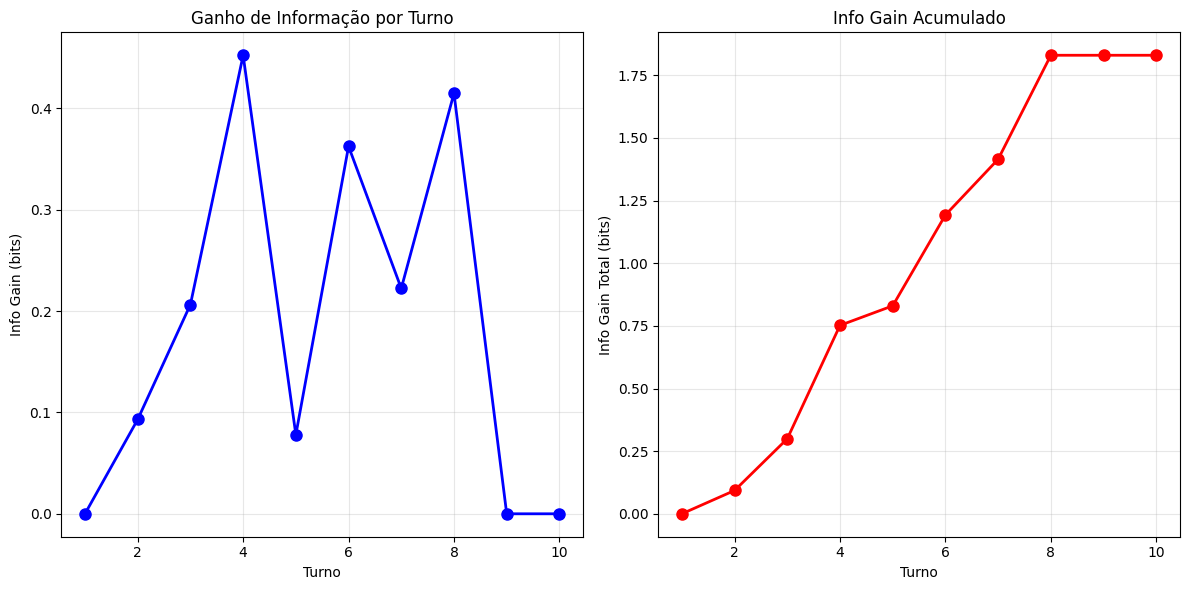

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Se você ainda não carregou os dados, use:
# df = pd.read_json("path/to/turns.jsonl", lines=True)

# 1. Plot básico do info_gain por turno
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(df['turn_index'], df['info_gain'], 'bo-', linewidth=2, markersize=8)
plt.title('Ganho de Informação por Turno')
plt.xlabel('Turno')
plt.ylabel('Info Gain (bits)')
plt.grid(True, alpha=0.3)

# 2. Plot com info_gain acumulado
plt.subplot(1, 2, 2)
df['cumulative_info_gain'] = df['info_gain'].cumsum()
plt.plot(df['turn_index'], df['cumulative_info_gain'], 'ro-', linewidth=2, markersize=8)
plt.title('Info Gain Acumulado')
plt.xlabel('Turno')
plt.ylabel('Info Gain Total (bits)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import glob

# Carregar todos os games
conversations_dir = "/Users/daniel2/Documents/AKCIT-RL/clary_quest/outputs/models/s_qwen3-8b__o_gpt-4o-mini__p_gpt-4o-mini/top40_po/conversations"
turns_files = glob.glob(f"{conversations_dir}/game_*/turns.jsonl")

all_data = []
for file in turns_files:
    df = pd.read_json(file, lines=True)
    game_id = Path(file).parent.name
    df['game_id'] = game_id
    all_data.append(df)

combined_df = pd.concat(all_data, ignore_index=True)

# Calcular média por turno
avg_per_turn = combined_df.groupby('turn_index')['info_gain'].agg(['mean', 'std', 'count']).reset_index()

# Plotar
plt.figure(figsize=(12, 6))
plt.errorbar(
    avg_per_turn['turn_index'], 
    avg_per_turn['mean'], 
    # yerr=avg_per_turn['std'], 
    capsize=5, 
    marker='o', 
    linewidth=2, 
    markersize=8
    )
plt.title('Ganho Médio de Informação por Turno')
plt.xlabel('Turno')
plt.ylabel('Info Gain Médio (bits)')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Analisados {combined_df['game_id'].nunique()} games")
avg_per_turn

ValueError: No objects to concatenate